# Análise de Evasão de Clientes - Telecom X

## Contexto do Projeto

###

A Telecom X está enfrentando um alto índice de cancelamentos de serviços. Este projeto utiliza a ciência de dados para investigar os motivos que levam os clientes a sair da empresa. O objetivo é transformar dados brutos em informações claras que ajudem a equipe a criar estratégias para manter esses clientes.

## Objetivo

Realizar a coleta, tratamento e análise de dados utilizando Python para extrair informações relevantes sobre o comportamento de clientes que cancelaram os serviços. Os resultados desta análise servirão como base para futuras iniciativas de retenção.

## Como o projeto foi construído (Processo ETL)

Para organizar as informações, foi seguido o método ETL (Extração, Transformação e Carga), que funciona como uma "linha de montagem" dos dados:

1. **Extração (Extract):** Importação via API.
2. **Transformação (Transform):** Esta é a fase de "preparo e refinamento". Como os dados brutos podem conter erros ou estar em formatos complexos, eles passam por uma limpeza profunda. As informações são padronizadas e organizadas para garantir que a análise final seja precisa e confiável.
3. **Análise Exploratória e Visualização:** Com os dados limpos, foram criados gráficos para "enxergar" padrões e descobrir quais tipos de clientes têm mais chance de cancelar o serviço.


## O que foi praticado
* Conexão direta com fontes de dados (APIs).
* Desaninhamento de colunas e dados estruturados.
* Organização e limpeza de dados complexos (ETL).
* Criação de gráficos estratégicos para tomada de decisão.
* Geração de relatórios com descobertas importantes (Insights).

---
**Ferramentas:** Python (Pandas, Matplotlib, Seaborn).


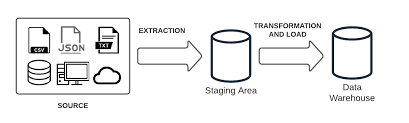



# 📌 Extração de Dados (Extract)

Nesta etapa, os dados são importados diretamente da API da Telecom X em formato JSON.



### Fonte dos Dados

🔗 **API**: [TelecomX_Data.json](https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/main/TelecomX_Data.json)

---

### Processo de Importação

1. Importação das bibliotecas necessárias
2. Definição da URL da API
3. Carregamento dos dados em um DataFrame

In [1]:
# 1. IMPORTAR AS BIBLIOTECAS NECESSÁRIAS
import pandas as pd

# 2. DEFINIR A URL DA API
url_api = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/main/TelecomX_Data.json'

# 3. CARREGAR OS DADOS DIRETAMENTE DA API EM UM DATAFRAME
df = pd.read_json(url_api)
df

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


### Observações da Extração

**Estrutura Identificada:**
- **Total de registros**: 7.267 linhas × 6 colunas
- **Colunas**: `customerID`, `Churn`, `customer`, `phone`, `internet`, `account`

**⚠️ Problema Identificado: Dados Aninhados**

As colunas `customer`, `phone`, `internet` e `account` contêm **dados aninhados** (dicionários/objetos JSON), não valores escalares. Cada célula contém múltiplos campos internos que precisam ser expandidos.

**Impacto:**
- A estrutura atual não é adequada para análise direta
- É necessário desaninhar esses campos na próxima etapa para obter uma estrutura tabular tradicional

# 🔧 Transformação de Dados (Transform)

Após a extração, os dados passam por um processo de transformação para garantir qualidade e consistência antes da análise.


### 1: Conhecendo o Dataset

Compreensão inicial da estrutura dos dados e identificação das variáveis disponíveis.

**Atividades:**
- 1.1. Desaninhar os dados para obter estrutura tabular
- 1.2. Consultar o [dicionário de dados](https://github.com/ingridcristh/challenge2-data-science/blob/main/TelecomX_dicionario.md) para entender o significado das variáveis
- 1.3. Realizar análise do perfil de churn
- 1.4. Identificar as variáveis mais relevantes para a análise

#### 1.1. Desaninhamento dos Dados

Os dados importados contêm colunas aninhadas que precisam ser expandidas. A função [`pd.json_normalize()`](https://pandas.pydata.org/docs/reference/api/pandas.json_normalize.html) é utilizada para desaninhar recursivamente todas as estruturas JSON. O método [`df.to_dict('records')`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_dict.html) converte o DataFrame em uma lista de dicionários, onde cada registro se torna um dicionário individual. O parâmetro `max_level=None` garante que todos os níveis sejam expandidos. Em seguida, os prefixos das colunas são removidos para facilitar o trabalho posterior.

In [2]:
# DESANINHAR TODOS OS NÍVEIS DE DADOS ANINHADOS
df = pd.json_normalize(df.to_dict('records'), max_level=None)
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [3]:
# REMOVER PREFIXOS DAS COLUNAS (customer., phone., internet., account.)
df.columns = df.columns.str.replace(r'^(customer|phone|internet|account)\.', '', regex=True)

df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#### 1.2. Consulta ao Dicionário de Dados



Análise do [dicionário de variáveis](https://github.com/ingridcristh/challenge2-data-science/blob/main/TelecomX_dicionario.md) para compreender o significado de cada coluna e sua relação com o comportamento de Churn.

**Estrutura das Variáveis:**

**Identificação eTarget**
- `customerID`: Identificador único do cliente
- `Churn`: **Variável alvo** - indica se houve cancelamento do serviço (Yes/No)

**Perfil Demográfico**
- `gender`: Gênero do cliente (Male/Female)
- `SeniorCitizen`: Indica se o cliente tem 65 anos ou mais (0=Não, 1=Sim)
- `Partner`: Possui parceiro(a) (Yes/No)
- `Dependents`: Possui dependentes (Yes/No)
- `tenure`: Tempo de relacionamento em meses

**Serviços de Telefonia**
- `PhoneService`: Possui serviço telefônico (Yes/No)
- `MultipleLines`: Possui múltiplas linhas telefônicas (Yes/No/No phone service)

**Serviços de Internet**
- `InternetService`: Tipo de internet contratada (DSL/Fiber optic/No)
- `OnlineSecurity`: Serviço de segurança online adicional
- `OnlineBackup`: Serviço de backup online adicional
- `DeviceProtection`: Proteção de dispositivos adicional
- `TechSupport`: Suporte técnico adicional
- `StreamingTV`: Streaming de TV
- `StreamingMovies`: Streaming de filmes

**Informações Contratuais e Financeiras**
- `Contract`: Tipo de contrato (Month-to-month/One year/Two year)
- `PaperlessBilling`: Faturamento eletrônico (Yes/No)
- `PaymentMethod`: Método de pagamento (Electronic check/Mailed check/Bank transfer/Credit card)
- `MonthlyCharges`: Valor cobrado mensalmente
- `TotalCharges`: Valor total pago durante o relacionamento

#### 1.3. Exploração Inicial e Perfil do Churn

Análise exploratória dos dados carregados, incluindo inspeção técnica para validar a integridade das informações e compreender a distribuição da variável alvo.

**Atividades realizadas:**
- **Inspeção de Tipos**: Verificação de como o Pandas interpretou as colunas (atualmente como objetos/texto)
- **Visualização de Amostra**: Observação das primeiras linhas para entender o formato dos dados
- **Proporção de Churn**: Cálculo percentual da evasão para entender o equilíbrio dos dados

In [4]:
# Ver informações gerais do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [5]:
# Análise Inicial do Alvo (Churn):
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869
,224


In [6]:
# Exibe a proporção percentual de Churn
df['Churn'].value_counts(normalize=True).mul(100)

,proportion
Churn,
No,71.198569
Yes,25.719004
,3.082427


#### 1.4. Identificação das Variáveis Relevantes para a Análise de Churn



Após explorar a estrutura do conjunto de dados e consultar o dicionário, foram selecionadas as colunas que possuem maior potencial para explicar a evasão de clientes:

- **Churn (Variável Alvo)**: Coluna principal que indica quem cancelou e quem permaneceu, servindo de base para toda a análise
- **tenure (Duração do relacionamento)**: Ajuda a entender se os cancelamentos acontecem mais com clientes novos ou se é um problema de retenção de clientes antigos
- **Contract (Tipo de Contrato)**: Essencial para verificar se contratos mensais (sem fidelidade) têm maior taxa de desistência do que contratos anuais
- **Charges (Custos Mensais e Totais)**: Permite analisar se o valor da conta pesa na decisão do cliente de cancelar o serviço
- **InternetService e TechSupport**: Variáveis ligadas à qualidade do serviço. Problemas técnicos ou falta de suporte são motivos frequentes para o abandono

### 2: Verificando Inconsistências nos Dados

Identificação e tratamento de problemas que possam comprometer a qualidade da análise, incluindo valores ausentes, duplicados, erros de formatação e inconsistências nas categorias.

**Atividades:**
- 2.1. Identificar valores ausentes
- 2.2. Verificar  registros duplicados
- 2.3. Validar tipos de dados e  formatações
- 2.4. Analisar valores categóricos
- 2.5. Verificar valores vazios ou em branco

#### 2.1. Identificar Valores Ausentes

Verificação da presença de valores ausentes (NaN, None, vazios) no dataset. A identificação desses valores é crucial para decidir a estratégia de tratamento adequada: preenchimento, remoção ou manutenção, dependendo do impacto na análise.

In [7]:
# VERIFICAR VALORES AUSENTES POR COLUNA
df.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


**Resultado da Verificação:**

O dataset não apresenta valores ausentes em nenhuma coluna, eliminando a necessidade de tratamento nesta etapa.

#### 2.2. Verificar Registros Duplicados

Identificação de registros duplicados no dataset que possam distorcer a análise. A presença de duplicatas pode inflar métricas e gerar conclusões enviesadas sobre o comportamento de Churn.

In [8]:
# VERIFICAR QUANTIDADE DE REGISTROS DUPLICADOS
df.duplicated().sum()

np.int64(0)

**Resultado da Verificação:**

O dataset não apresenta registros duplicados, garantindo a integridade e unicidade dos dados para análise.

#### 2.3. Validar Tipos de Dados Formatações

Verificação dos tipos de dados atribuídos a cada coluna pelo Pandas e correção de inconsistências. Colunas numéricas interpretadas como texto ou datas em formato inadequado podem comprometer cálculos e análises estatísticas.

In [9]:
# IDENTIFICAR COLUNAS QUE DEVERIAM SER NUMÉRICAS
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


**Resultado da Verificação:**

**Tipos de dados identificados:**
- **Numéricas corretas**: `SeniorCitizen` (int64), `tenure` (int64), `Charges.Monthly` (float64)
- **Variáveis categóricas**: Maioria das colunas está como `object`, o que é adequado para dados textuais
- **Atenção**: `Charges.Total` está como `object` quando deveria ser numérica (float64)

**Inconsistências identificadas:**
A coluna `Charges.Total` precisa ser convertida para tipo numérico na próxima fase de tratamento, pois atualmente está sendo interpretada como texto.

#### 2.4. Analisar Valores Categóricos

Verificação dos valores únicos presentes nas variáveis categóricas para identificar possíveis inconsistências como: variações de escrita (maiúsculas/minúsculas), espaços em branco, categorias inesperadas ou erros de digitação que possam prejudicar agrupamentos e análises.

In [10]:
# VERIFICAR VALORES ÚNICOS DAS COLUNAS CATEGÓRICAS
df.select_dtypes(include='object').apply(lambda x: x.unique())

,0
customerID,"[0002-ORFBO, 0003-MKNFE, 0004-TLHLJ, 0011-IGKF..."
Churn,"[No, Yes, ]"
gender,"[Female, Male]"
Partner,"[Yes, No]"
Dependents,"[Yes, No]"
PhoneService,"[Yes, No]"
MultipleLines,"[No, Yes, No phone service]"
InternetService,"[DSL, Fiber optic, No]"
OnlineSecurity,"[No, Yes, No internet service]"
OnlineBackup,"[Yes, No, No internet service]"


**Resultado da Verificação:**

**Inconsistências identificadas:**

1. **customerID**: Contém 7.267 IDs únicos - não requer análise de consistência por ser identificador

2. **Variáveis com padrão consistente**:
   - `Churn`: [No, Yes]
   - `gender`: [Female, Male]
   - `Partner`, `Dependents`, `PhoneService`, `PaperlessBilling`: [Yes, No]

3. **Variáveis com valores adicionais**:
   - `MultipleLines`: [No, Yes, **No phone service**]
   - `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`: [No, Yes, **No internet service**]
   
4. **Contract**: [One year, Month-to-month, Two year] - valores consistentes

5. **PaymentMethod**: [Mailed check, Electronic check, Credit card, ...] - requer verificação completa dos valores

6. **Charges.Total**: Valores numéricos armazenados como texto (ex: 593.3, 542.4, 280.85...) - confirma necessidade de conversão identificada no item 2.3

**Principais achados para tratamento:**
- Valores "No phone service" e "No internet service" podem ser padronizados
- `Charges.Total` precisa ser convertida para tipo numérico

#### 2.5. Verificar Valores Vazios ou em Branco

Identificação de valores que não são tecnicamente nulos (NaN), mas estão vazios como strings vazias ('') ou contêm apenas espaços em branco. Esses valores podem passar despercebidos na verificação de nulos tradicional, mas ainda assim comprometem a qualidade da análise.

In [11]:
# VERIFICAR VALORES VAZIOS (STRINGS VAZIAS) EM CADA COLUNA
valores_vazios = (df == '').sum()
valores_vazios[valores_vazios > 0]

,0
Churn,224


In [12]:
# VERIFICAR VALORES COM APENAS ESPAÇOS EM BRANCO
valores_espacos = df.apply(lambda x: x.astype(str).str.strip().eq('').sum())
valores_espacos[valores_espacos > 0]

,0
Churn,224
Charges.Total,11


**Resultado da Verificação:**

**Valores vazios identificados:**

1. **Churn**: 224 registros com strings vazias ('')
   - Representa aproximadamente 3,08% do dataset (confirmando a análise do item 1.3)
   - Estes registros não podem ser utilizados na análise de evasão, pois não sabemos se o cliente cancelou ou não

2. **Charges.Total**: 11 registros com valores vazios ou apenas espaços em branco
   - Pequeno percentual, mas crítico por ser uma variável financeira importante
   - Pode indicar problemas no sistema de cobrança ou registro incompleto

**Impacto para a análise:**
- Os 224 registros sem informação de Churn precisam ser removidos na etapa de tratamento, pois a variável alvo é essencial para a análise
- Os 11 registros com `Charges.Total` vazio também precisarão ser tratados (remoção ou imputação)
- As demais colunas não apresentam valores vazios ou em branco

### 3: Tratando as Inconsistências

Agora, com as inconsistências identificadas, é hora de aplicar as correções necessárias. Ajuste os dados para garantir que estejam completos e coerentes, preparando-os para as próximas etapas da análise.

**Atividades:**
- 3.1. Remover registros com valores ausentes na variável alvo (Churn)
- 3.2. Converter e tratar valores da coluna Charges.Total
- 3.3. Padronizar valores categóricos inconsistentes
- 3.4. Validar dataset após tratamento

#### 3.1. Remover Registros com Valores Ausentes na Variável Alvo (Churn)

Remoção dos 224 registros que não possuem informação sobre a variável alvo (Churn). Como esta é a variável que queremos analisar, registros sem essa informação não podem contribuir para o estudo de evasão.

In [13]:
# REMOVER REGISTROS COM CHURN VAZIO OU COM APENAS ESPAÇOS
df = df[df['Churn'].str.strip() != '']

df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


#### 3.2. Converter e Tratar Valores da Coluna Charges.Total

Conversão da coluna `Charges.Total` de texto (object) para tipo numérico (float). Durante a verificação (item 2.3), identificamos que esta coluna está armazenada como texto, impossibilitando cálculos e análises estatísticas. Além disso, 11 registros possuem valores vazios que precisam ser tratados.

Para remoção de valores nulos, utilizamos o método [`.dropna()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html) com o parâmetro `subset` para especificar a coluna a ser verificada.

In [14]:
# CONVERTER CHARGES.TOTAL PARA NUMÉRICO
# O parâmetro errors='coerce' transforma valores inválidos em NaN
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')

# VERIFICAR TIPO DE DADO APÓS CONVERSÃO
df['Charges.Total'].dtype

dtype('float64')

In [15]:
# VERIFICAR QUANTIDADE DE VALORES NULOS GERADOS NA CONVERSÃO
df['Charges.Total'].isnull().sum()

np.int64(11)

In [16]:
# REMOVER REGISTROS COM CHARGES.TOTAL NULO
df = df.dropna(subset=['Charges.Total'])

# CONFIRMAR REMOÇÃO
df['Charges.Total'].isnull().sum()

np.int64(0)

#### 3.3. Padronizar Valores Categóricos Inconsistentes

Padronização dos valores categóricos identificados no item 2.4 que apresentam inconsistências. Especificamente, os valores "No phone service" e "No internet service" serão convertidos para "No" para simplificar a análise, já que funcionalmente significam a ausência do serviço.

In [17]:
# CRIAR BACKUP DO DATASET ANTES DA PADRONIZAÇÃO (MEDIDA DE SEGURANÇA)
df_backup = df.copy()
df_backup.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [18]:
# LISTA DE COLUNAS QUE CONTÊM "No phone service" OU "No internet service"
colunas_servicos = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

# SUBSTITUIR VALORES LONGOS POR "No"
for coluna in colunas_servicos:
    df[coluna] = df[coluna].replace({
        'No phone service': 'No',
        'No internet service': 'No'
    })

# VERIFICAR RESULTADO DA PADRONIZAÇÃO
df[colunas_servicos].apply(lambda x: x.unique())

,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,No,No,Yes,No,Yes,Yes,No
1,Yes,Yes,No,Yes,No,No,Yes


#### 3.4. Validação Final do Dataset Tratado

Verificação completa do dataset após todas as correções para garantir que os dados estão consistentes, completos e prontos para as próximas etapas.

**Checklist de Validação:**
- Nenhum valor ausente (NaN)
- Nenhuma string vazia
- Tipos de dados corretos
- Valores categóricos padronizados
- Charges.Total convertida para float64

In [19]:
# INFORMAÇÕES GERAIS DO DATASET TRATADO
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   Churn             7032 non-null   object 
 2   gender            7032 non-null   object 
 3   SeniorCitizen     7032 non-null   int64  
 4   Partner           7032 non-null   object 
 5   Dependents        7032 non-null   object 
 6   tenure            7032 non-null   int64  
 7   PhoneService      7032 non-null   object 
 8   MultipleLines     7032 non-null   object 
 9   InternetService   7032 non-null   object 
 10  OnlineSecurity    7032 non-null   object 
 11  OnlineBackup      7032 non-null   object 
 12  DeviceProtection  7032 non-null   object 
 13  TechSupport       7032 non-null   object 
 14  StreamingTV       7032 non-null   object 
 15  StreamingMovies   7032 non-null   object 
 16  Contract          7032 non-null   object 
 17  

In [20]:
# VERIFICAR VALORES AUSENTES
df.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [21]:
# VERIFICAR VALORES VAZIOS (STRINGS VAZIAS)
(df == '').sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [22]:
# VISUALIZAR AMOSTRA DO DATASET TRATADO
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [23]:
# RESUMO: TOTAL DE REGISTROS APÓS TRATAMENTO
print(f"Total de registros finais: {len(df)}")
print(f"Registros removidos no tratamento: {7267 - len(df)}")

Total de registros finais: 7032
Registros removidos no tratamento: 235


#### Resumo da Etapa 3: Tratamento de Inconsistências



**Ações Realizadas:**

1. **Remoção de registros inválidos:**
   - 224 registros sem informação de Churn
   - 11 registros com Charges.Total inválido
   - Total removido: 235 registros (3,2%)

2. **Conversão de tipos:**
   - `Charges.Total`: object → float64

3. **Padronização categórica:**
   - "No phone service" e "No internet service" → "No"
   - 7 colunas padronizadas

**Dataset Final:**
- Registros: 7.032 (de 7.267 originais)
- Valores ausentes: 0
- Valores vazios: 0
- Status: ✓ Limpo e validado

**Próxima etapa:** Criação da coluna de Contas Diárias.

### 4: Coluna de Contas Diárias (Opcional)

Criação de uma nova coluna chamada `Charges.Daily` que representa o custo diário do serviço. O cálculo é feito dividindo o valor mensal por 30 dias.

**Por que isso é útil?**

Conhecer o custo diário ajuda a entender melhor como os clientes percebem o valor do serviço. Pode revelar padrões interessantes quando comparada com o tempo de permanência (tenure) e auxiliar na identificação de correlações entre custo diário e decisão de cancelamento.

In [24]:
# CALCULAR VALOR DIÁRIO A PARTIR DO VALOR MENSAL
df['Charges.Daily'] = (df['Charges.Monthly'] / 30).round(2)
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Charges.Daily
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80


### 5: Padronização e Transformação de Dados (Opcional)

Esta etapa tem como objetivo preparar melhor os dados para análises mais avançadas. Aqui serão realizadas duas transformações opcionais:

**1. Conversão de textos para números:** Transformar valores como "Yes"/"No" em 1/0 facilita cálculos estatísticos e criação de gráficos de correlação.

**2. Tradução das colunas:** Renomear as colunas para português torna o dataset mais acessível, especialmente ao apresentar resultados para equipes ou gestores que não trabalham com termos técnicos em inglês.

Ambas as transformações são opcionais e podem ser aplicadas conforme a necessidade da análise ou preferência de apresentação dos resultados.

#### 5.1. Transformação de Dados Categóricos em Binários

Conversão de valores textuais como "Yes"/"No" e "Male"/"Female" em valores numéricos 1 e 0.

**Por que fazer essa conversão?**

Valores numéricos permitem operações matemáticas diretas. Por exemplo, calcular a média de clientes que possuem parceiro ou a correlação entre ter dependentes e cancelar o serviço se torna mais simples quando os dados estão em formato binário.

**Legenda das conversões:**
- **Colunas Yes/No:** 1 = Yes (possui/sim), 0 = No (não possui/não)
- **Gender (Gênero):** 1 = Male (masculino), 0 = Female (feminino)

In [25]:
# CONVERTER YES/NO PARA 1/0
colunas_yes_no = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                  'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                  'TechSupport', 'StreamingTV', 'StreamingMovies',
                  'PaperlessBilling', 'Churn']

df[colunas_yes_no] = df[colunas_yes_no].replace({'Yes': 1, 'No': 0})
df.head()

/tmp/ipython-input-481170116.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[colunas_yes_no] = df[colunas_yes_no].replace({'Yes': 1, 'No': 0})


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Charges.Daily
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.80


In [26]:
# CONVERTER MALE/FEMALE PARA 1/0
df['gender'] = df['gender'].replace({'Male': 1, 'Female': 0})
df.head()

/tmp/ipython-input-1488043986.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['gender'] = df['gender'].replace({'Male': 1, 'Female': 0})


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Charges.Daily
0,0002-ORFBO,0,0,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,1,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,1,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,1,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,0,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.80


#### 5.2. Renomear Colunas para Português

Tradução dos nomes das colunas do inglês para o português, facilitando a leitura e interpretação dos dados, especialmente em apresentações e relatórios.

In [27]:
# DICIONÁRIO DE TRADUÇÃO
traducao = {
    'customerID': 'ID_Cliente',
    'Churn': 'Cancelamento',
    'gender': 'Genero',
    'SeniorCitizen': 'Idoso',
    'Partner': 'Tem_Parceiro',
    'Dependents': 'Tem_Dependentes',
    'tenure': 'Meses_Contrato',
    'PhoneService': 'Servico_Telefone',
    'MultipleLines': 'Multiplas_Linhas',
    'InternetService': 'Serviço_Internet',
    'OnlineSecurity': 'Seguranca_Online',
    'OnlineBackup': 'Backup_Online',
    'DeviceProtection': 'Protecao_Dispositivo',
    'TechSupport': 'Suporte_Tecnico',
    'StreamingTV': 'Streaming_TV',
    'StreamingMovies': 'Streaming_Filmes',
    'Contract': 'Tipo_Contrato',
    'PaperlessBilling': 'Fatura_Digital',
    'PaymentMethod': 'Forma_Pagamento',
    'Charges.Monthly': 'Cobranca_Mensal',
    'Charges.Total': 'Cobranca_Total',
    'Charges.Daily': 'Cobranca_Diaria'
}

# APLICAR TRADUÇÃO
df = df.rename(columns=traducao)
df.head()

,ID_Cliente,Cancelamento,Genero,Idoso,Tem_Parceiro,Tem_Dependentes,Meses_Contrato,Servico_Telefone,Multiplas_Linhas,Serviço_Internet,...,Protecao_Dispositivo,Suporte_Tecnico,Streaming_TV,Streaming_Filmes,Tipo_Contrato,Fatura_Digital,Forma_Pagamento,Cobranca_Mensal,Cobranca_Total,Cobranca_Diaria
0,0002-ORFBO,0,0,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,1,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,1,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,1,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,0,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.80


# 📊 Carga e Análise (Load & Analysis)

Com os dados limpos e transformados, agora é o momento de carregá-los para análise e criar visualizações estratégicas que revelem padrões sobre o comportamento de evasão dos clientes.

### Sobre a Análise Exploratória

A análise exploratória é como uma investigação detalhada dos dados. Nesta fase, serão criados gráficos e calculadas estatísticas para "enxergar" padrões e descobrir quais tipos de clientes têm mais chance de cancelar o serviço. As visualizações transformam números em histórias visuais, facilitando a identificação de fatores críticos para a retenção.



### 1: Análise Descritiva

Cálculo de métricas estatísticas como média, mediana, desvio padrão e outras medidas que ajudam a entender melhor a distribuição e o comportamento dos clientes.

**O que será analisado:**
Esta análise fornece uma visão geral dos dados numéricos, identificando valores centrais, dispersão e possíveis outliers que podem influenciar a análise de evasão.

#### 1.1. Análise Estatística: Variáveis Numéricas e Binárias

In [28]:
# ESTATÍSTICAS DESCRITIVAS: Variáveis Numéricas e Indicadores Binários
df.describe()

,Cancelamento,Genero,Idoso,Tem_Parceiro,Tem_Dependentes,Meses_Contrato,Servico_Telefone,Multiplas_Linhas,Seguranca_Online,Backup_Online,Protecao_Dispositivo,Suporte_Tecnico,Streaming_TV,Streaming_Filmes,Fatura_Digital,Cobranca_Mensal,Cobranca_Total,Cobranca_Diaria
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.265785,0.504693,0.162400,0.482509,0.298493,32.421786,0.903299,0.421928,0.286547,0.344852,0.343857,0.290102,0.384386,0.388367,0.592719,64.798208,2283.300441,2.159891
std,0.441782,0.500014,0.368844,0.499729,0.457629,24.545260,0.295571,0.493902,0.452180,0.475354,0.475028,0.453842,0.486484,0.487414,0.491363,30.085974,2266.771362,1.002955
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.610000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.587500,401.450000,1.187500
50%,0.000000,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.350000,1397.475000,2.340000
75%,1.000000,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.862500,3794.737500,2.992500
max,1.000000,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000,3.960000


#### 1.2. Visualização: Distribuição das Variáveis Numéricas


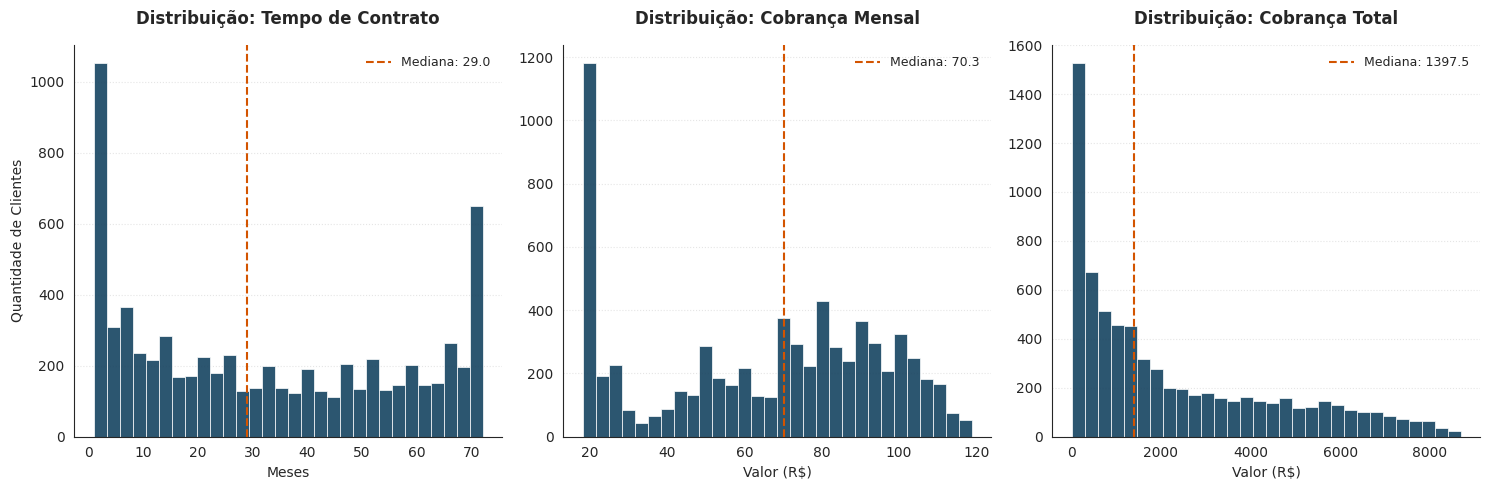

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. DEFINIR CORES MAIS SÉRIAS E PROFISSIONAIS
COR_PRINCIPAL = '#154360'  # Azul Marinho Escuro (Premium)
COR_KDE = '#2980B9'        # Azul médio para a linha de contorno
COR_MEDIANA = '#D35400'    # Contraste para a mediana (opcional)

# Configurar estilo clean
sns.set_style("white")

# Criar figura com 3 gráficos
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Dados e Labels para o loop
colunas = ['Meses_Contrato', 'Cobranca_Mensal', 'Cobranca_Total']
titulos = ['Distribuição: Tempo de Contrato', 'Distribuição: Cobrança Mensal', 'Distribuição: Cobrança Total']
x_labels = ['Meses', 'Valor (R$)', 'Valor (R$)']

for i, col in enumerate(colunas):
    # Gráfico com KDE para visualização moderna
    sns.histplot(df[col], bins=30, color=COR_PRINCIPAL,
                 ax=axes[i], edgecolor='white', linewidth=0.5, alpha=0.9)

    # Adicionar Mediana como referência técnica
    mediana = df[col].median()
    axes[i].axvline(mediana, color=COR_MEDIANA, linestyle='--', linewidth=1.5, label=f'Mediana: {mediana:.1f}')

    # Títulos e Eixos
    axes[i].set_title(titulos[i], fontsize=12, fontweight='bold', pad=15)
    axes[i].set_xlabel(x_labels[i])
    axes[i].set_ylabel('Quantidade de Clientes' if i == 0 else '')

    # REMOVER CONTORNOS (Direita e Superior)
    sns.despine(ax=axes[i])

    # Grid sutil apenas no eixo Y
    axes[i].yaxis.grid(True, linestyle=':', alpha=0.5)
    axes[i].legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.show()

#### 1.3. Visualização: Distribuição das Variáveis Binárias

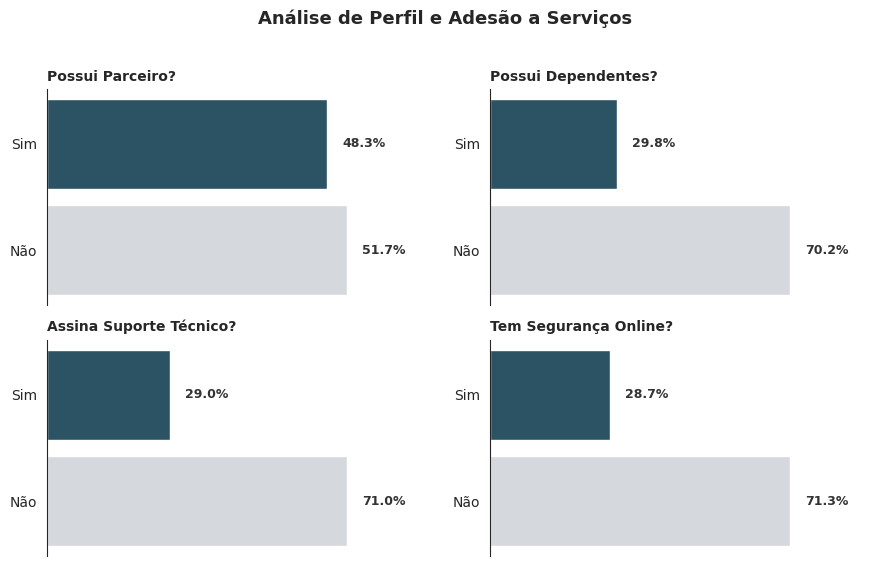

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações Finais de Estilo
COR_SIM, COR_NAO = '#2C5364', '#D5D8DC'
sns.set_style("white")

variaveis = ['Tem_Parceiro', 'Tem_Dependentes', 'Suporte_Tecnico', 'Seguranca_Online']
titulos = ['Possui Parceiro?', 'Possui Dependentes?', 'Assina Suporte Técnico?', 'Tem Segurança Online?']

# tamanho e alinhamento
fig, axes = plt.subplots(2, 2, figsize=(9, 5.5))
fig.suptitle('Análise de Perfil e Adesão a Serviços', fontsize=13, fontweight='bold', y=1.02)

for i, ax in enumerate(axes.flat):
    col = variaveis[i]
    counts = df[col].value_counts().sort_index()
    perc = df[col].value_counts(normalize=True).sort_index() * 100

    # height=0.85 para barras mais robustas e menos espaço vazio
    bars = ax.barh(['Não', 'Sim'], counts.values, color=[COR_NAO, COR_SIM], height=0.85)

    # Rótulos com leve recuo para não encostar na borda da imagem
    for j, bar in enumerate(bars):
        ax.text(bar.get_width() + (counts.max() * 0.05), bar.get_y() + bar.get_height()/2,
                f'{perc.values[j]:.1f}%', va='center', fontweight='bold', fontsize=9, color='#333')

    ax.set_title(titulos[i], fontsize=10, fontweight='bold', loc='left')
    ax.set_xticks([])

    # Define um limite X folgado para o texto não ser cortado
    ax.set_xlim(0, counts.max() * 1.3)

    # Padrão sem bordas laterais/superiores
    sns.despine(ax=ax, bottom=True)

plt.tight_layout()
plt.show()

**Principais Observações - Variáveis Numéricas e Binárias:**

- **Taxa de Cancelamento:** 26,6% dos clientes cancelaram o serviço (1.869 de 7.032 clientes)
- **Tempo de Relacionamento:**
  - Média de 32 meses com alta concentração de clientes novos (0-5 meses)
  - Possível indicativo de dificuldade na retenção inicial
- **Valores Cobrados:**
  - Cobrança mensal média de R\$ 64,80
  - Dois picos distintos: ~R\$ 20 (plano básico) e R\$ 70-100 (plano completo)
  - Ausência de produtos intermediários
  - Cobranças totais refletem o tempo de relacionamento
- **Perfil Demográfico:**
  - Base equilibrada entre gêneros (50/50) e entre clientes com/sem parceiro
  - Baixa proporção de idosos (16%)
  - Maioria sem dependentes (70%)
- **Serviços Adicionais:**
  - Maioria não contrata suporte técnico nem segurança online
  - Indica preferência por planos mais básicos

**Questões para Aprofundamento:**

➤ Qual o período crítico onde ocorrem mais cancelamentos?  
➤ Existe relação entre valor cobrado e taxa de evasão?  
➤ Há diferença na taxa de cancelamento entre planos básicos e completos?  
➤ Clientes sem dependentes cancelam mais?  
➤ Clientes sem serviços adicionais (suporte e segurança) têm maior taxa de cancelamento?

#### 1.4. Análise Estatística: Variáveis Categóricas

In [31]:
# ESTATÍSTICAS DESCRITIVAS DAS VARIÁVEIS CATEGÓRICAS
df.describe(include='object')

,ID_Cliente,Serviço_Internet,Tipo_Contrato,Forma_Pagamento
count,7032,7032,7032,7032
unique,7032,3,3,4
top,9995-HOTOH,Fiber optic,Month-to-month,Electronic check
freq,1,3096,3875,2365


#### 1.5 Visualização: Distribuição das Variáveis Categóricas

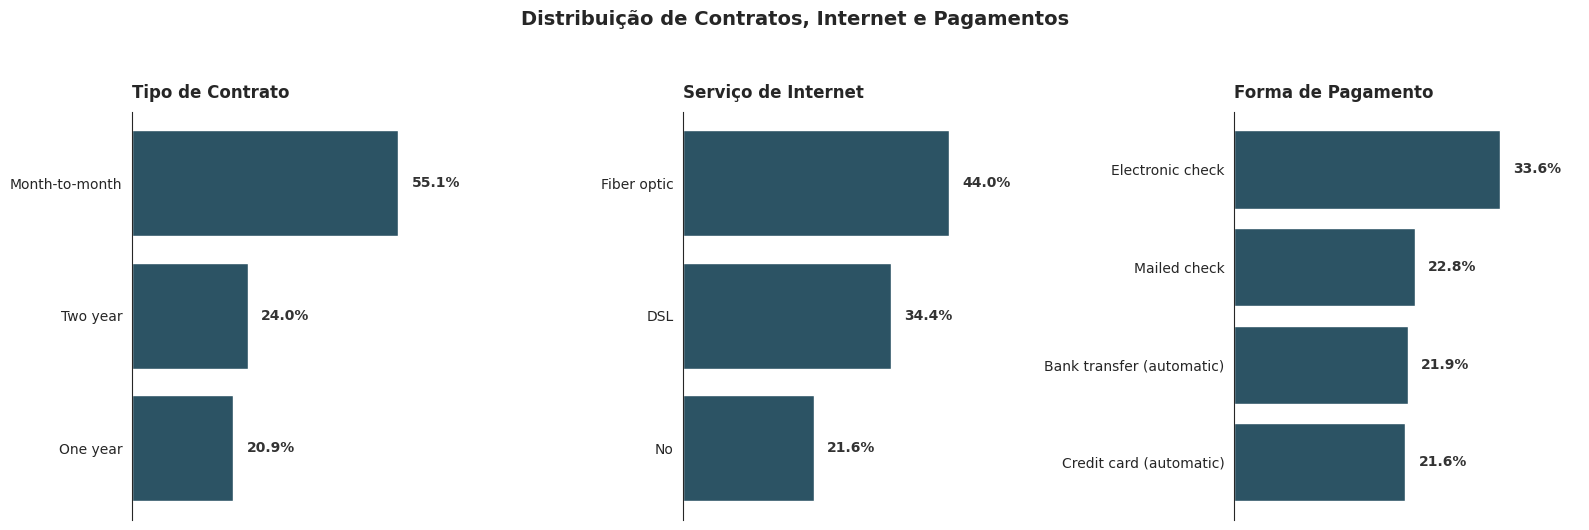

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CORES (Mantendo o seu padrão Azul Petróleo)
COR_BARRA = '#2C5364'
sns.set_style("white")

variaveis = ['Tipo_Contrato', 'Serviço_Internet', 'Forma_Pagamento']
titulos = ['Tipo de Contrato', 'Serviço de Internet', 'Forma de Pagamento']

# 2. FIGURA
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribuição de Contratos, Internet e Pagamentos', fontsize=14, fontweight='bold', y=1.05)

for i, ax in enumerate(axes.flat):
    # Ordenação do maior para o menor para facilitar a comparação visual
    counts = df[variaveis[i]].value_counts().sort_values(ascending=True)
    perc = (counts / counts.sum()) * 100

    # Barras com altura 0.8 para ficarem mais próximas entre si
    bars = ax.barh(counts.index, counts.values, color=COR_BARRA, height=0.8)

    # Adicionando o rótulo com um 'offset' fixo baseado no valor máximo do gráfico atual
    max_val = counts.max()
    for j, bar in enumerate(bars):
        ax.text(bar.get_width() + (max_val * 0.05), bar.get_y() + bar.get_height()/2,
                f'{perc.values[j]:.1f}%',
                va='center', fontweight='bold', fontsize=10, color='#333')

    # Ajustes de Limpeza (sem bordas laterais/superiores)
    ax.set_title(titulos[i], fontsize=12, fontweight='bold', loc='left', pad=10)
    ax.set_xticks([]) # Remove o eixo X para não poluir
    ax.set_xlim(0, max_val * 1.3) # Dá 30% de folga na direita para o texto não ser cortado
    sns.despine(ax=ax, bottom=True) # Remove borda de baixo também, já que não tem eixo X

plt.tight_layout()
plt.show()

**Principais Observações - Variáveis Categóricas:**

- **Tipo de Contrato:** Mais de 55% dos clientes estão em contratos mensais (Month-to-month), facilitando o cancelamento pela ausência de fidelidade
- **Serviço de Internet:** Fibra Ótica é a mais popular (3.096 clientes), seguida por DSL
- **Forma de Pagamento:** Electronic check é o método predominante (2.365 clientes), podendo estar associado a menor barreira de saída

**Questões para Aprofundamento:**

➤ Existe correlação entre tipo de contrato e taxa de cancelamento?  
➤ O tipo de internet contratada influencia na taxa de cancelamento?  
➤ O método de pagamento influencia na decisão de cancelar?

#### 1.6. Síntese da Análise Descritiva



**Perfil de Risco Identificado:**

A análise descritiva revela uma base de clientes com **26,6% de taxa de cancelamento**, apresentando três fatores de risco principais:

1. **Baixa Fidelização Contratual:** 55% em contratos mensais sem barreiras de saída
2. **Retenção Inicial Crítica:** Alta concentração de evasão nos primeiros 5 meses
3. **Baixa Adesão a Serviços:** Maioria sem produtos adicionais que aumentem o vínculo

A polarização de valores (R\$ 20 vs R\$ 70-100) e o perfil predominantemente sem dependentes sugerem uma base vulnerável a ofertas competitivas.

---

**Questões Identificadas para Investigação nas Próximas Análises:**

1. ➤ Qual o período crítico onde ocorrem mais cancelamentos?
2. ➤ Existe relação entre valor cobrado e taxa de evasão?
3. ➤ Há diferença na taxa de cancelamento entre planos básicos e completos?
4. ➤ Clientes sem dependentes cancelam mais?
5. ➤ Clientes sem serviços adicionais (suporte e segurança) têm maior taxa de cancelamento?
6. ➤ Existe correlação entre tipo de contrato e taxa de cancelamento?
7. ➤ O tipo de internet contratada influencia na taxa de cancelamento?
8. ➤ O método de pagamento influencia na decisão de cancelar?

---

**Próximos Passos:**

As análises seguintes irão investigar as relações entre essas variáveis e o comportamento de cancelamento, respondendo às questões levantadas e identificando os fatores críticos que levam à evasão de clientes.

### 2: Distribuição da Evasão

Compreensão de como a variável "Churn" (evasão) está distribuída entre os clientes. Visualização da proporção de clientes que permaneceram versus os que cancelaram o serviço.

**Objetivo:**
Identificar o percentual de evasão e avaliar se o dataset está balanceado ou desbalanceado em relação à variável alvo.

#### 2.1. Proporção Geral da Evasão

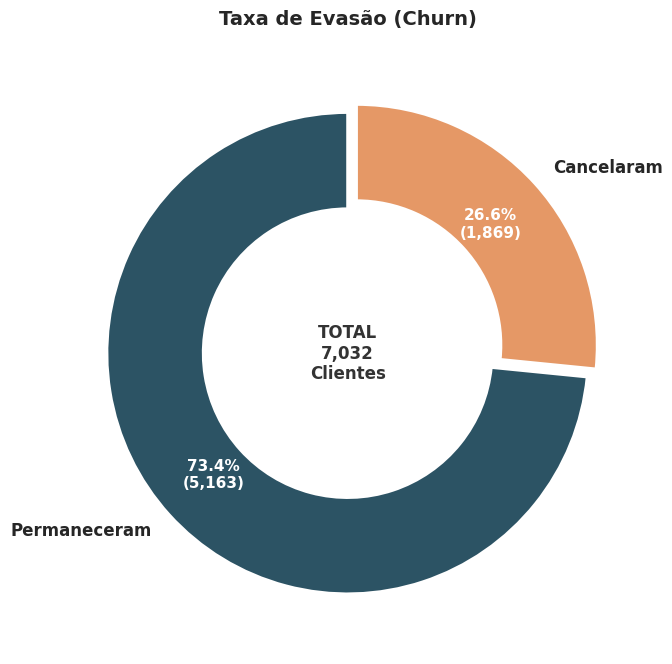

In [76]:
import matplotlib.pyplot as plt

# 1. DEFINIÇÃO DE CORES (Consistência com padrão)
COR_PERMANECEU = '#2C5364' # Seu Azul Petróleo
COR_CANCELOU = '#E59866'   # Coral sóbrio

# 2. PREPARAÇÃO DOS DADOS
valores = df['Cancelamento'].value_counts()
total_clientes = valores.sum()
labels = ['Permaneceram', 'Cancelaram']

# 3. CRIAÇÃO DO GRÁFICO DE ROSCA
fig, ax = plt.subplots(figsize=(7, 7))

# Função para exibir % e Valor absoluto
def func(pct, allvals):
    absolute = int(round(pct/100.*sum(allvals)))
    return f"{pct:.1f}%\n({absolute:,})"

# Desenho das fatias (width define o tamanho do furo da rosca)
wedges, texts, autotexts = ax.pie(
    valores,
    labels=labels,
    autopct=lambda pct: func(pct, valores),
    startangle=90,
    colors=[COR_PERMANECEU, COR_CANCELOU],
    pctdistance=0.75, # Aproxima o texto do centro da fatia
    explode=(0, 0.05), # Destaque leve para a evasão
    wedgeprops={'width': 0.4, 'edgecolor': 'white', 'linewidth': 2}
)

# Estilização dos textos internos
plt.setp(autotexts, size=11, weight="bold", color="white")
plt.setp(texts, size=12, weight="bold")

# 4. TEXTO CENTRAL (Total de Clientes)
ax.text(0, 0, f'TOTAL\n{total_clientes:,}\nClientes',
        ha='center', va='center', fontsize=12, fontweight='bold', color='#333')

# Título Limpo
ax.set_title('Taxa de Evasão (Churn)', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

### 3: Contagem de Evasão por Variáveis Categóricas

Exploração de como a evasão se distribui de acordo com variáveis categóricas como gênero, tipo de contrato, método de pagamento, tipo de internet, entre outras.

**Por que isso importa:**
Esta análise pode revelar padrões interessantes, como se clientes de determinados perfis têm maior tendência a cancelar o serviço, direcionando ações estratégicas de retenção para grupos específicos.

#### 3.1. Evasão por Tipo de Contrato

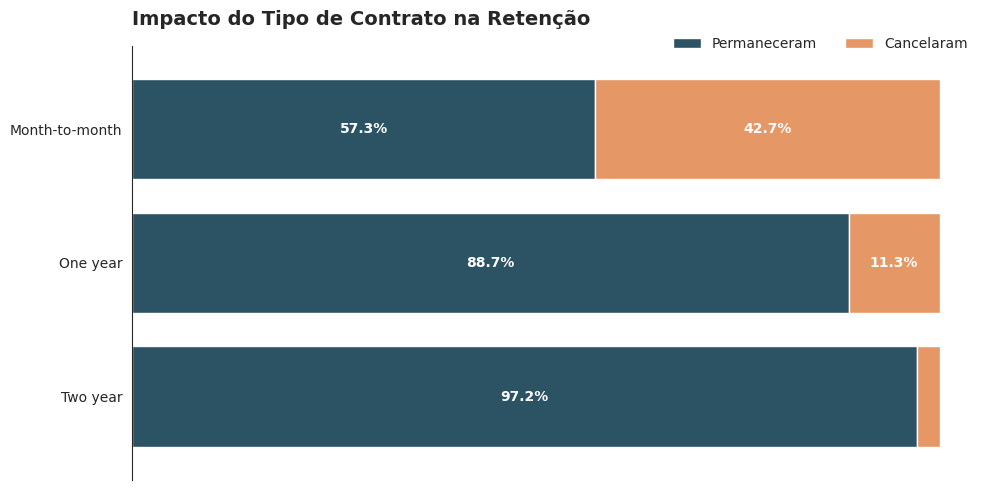

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

# DEFINIR CORES  PADRÃO
COR_PERMANECEU, COR_CANCELOU = '#2C5364', '#E59866' # Azul Petróleo e Coral
sns.set_style("white")

# 1. PREPARAR DADOS (Crosstab Dinâmico)
contrato_churn = pd.crosstab(df['Tipo_Contrato'], df['Cancelamento'], normalize='index') * 100

# Ordenação dinâmica pelo Churn
col_churn = contrato_churn.columns[-1]
contrato_churn = contrato_churn.sort_values(by=col_churn, ascending=True)

# 2. VISUALIZAÇÃO
fig, ax = plt.subplots(figsize=(10, 5))

# Plot empilhado (stacked=True) para limpeza visual
contrato_churn.plot(kind='barh', stacked=True, ax=ax, color=[COR_PERMANECEU, COR_CANCELOU], width=0.75)

# Título e Legenda
ax.set_title('Impacto do Tipo de Contrato na Retenção', fontsize=14, fontweight='bold', loc='left', pad=15)
ax.legend(['Permaneceram', 'Cancelaram'], bbox_to_anchor=(1, 1.05), ncol=2, frameon=False)

# 3. ADICIONAR PERCENTUAIS DENTRO DAS BARRAS (Destaque do insight)
for i in range(len(contrato_churn)):
    # Valor da primeira fatia (Não Cancelou)
    val_nao = contrato_churn.iloc[i, 0]
    ax.text(val_nao/2, i, f'{val_nao:.1f}%', va='center', ha='center', color='white', fontweight='bold')

    # Valor da segunda fatia (Cancelou)
    val_sim = contrato_churn.iloc[i, 1]
    if val_sim > 5: # Só exibe se houver espaço na barra
        ax.text(val_nao + (val_sim/2), i, f'{val_sim:.1f}%', va='center', ha='center', color='white', fontweight='bold')

# 4. LIMPEZA FINAL (sem bordas e sem eixos redundantes)
ax.set_xticks([])
ax.set_ylabel('')
ax.set_xlabel('')
sns.despine(ax=ax, bottom=True)

plt.tight_layout()
plt.show()

**Principais Observações:**

- **Contratos mensais apresentam taxa crítica de cancelamento:** 42,7% dos clientes em Month-to-month cancelaram, enquanto contratos anuais (One year) têm apenas 11,3% e bianuais (Two year) apenas 2,8%
- A ausência de fidelidade contratual é um fator de risco significativo para evasão
- Contratos com compromisso de longo prazo reduzem drasticamente o cancelamento

➤ **Responde à questão 6:** Sim, existe forte correlação entre tipo de contrato e taxa de cancelamento

#### 3.2. Evasão por Serviço de Internet

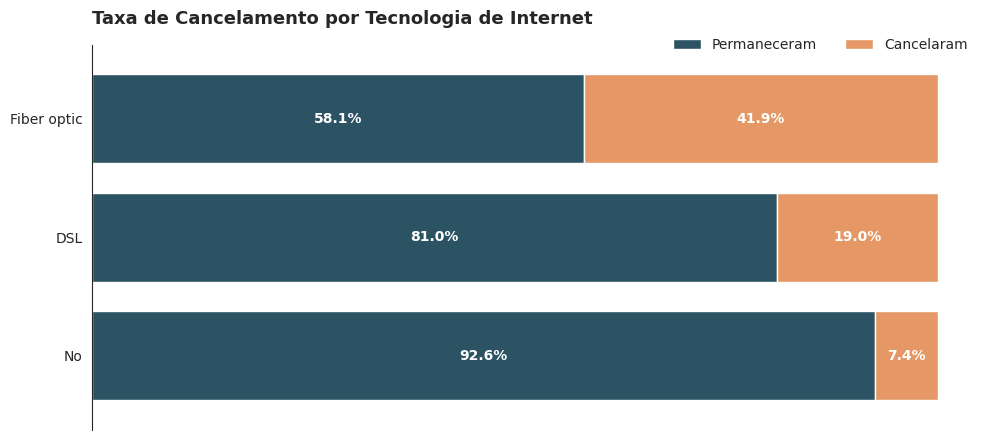

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CONFIGURAÇÕES (Padrão Unificado)
COR_PERMANECEU, COR_CANCELOU = '#2C5364', '#E59866'
sns.set_style("white")

# 2. PREPARAR DADOS
# Tabela cruzada normalizada para análise de proporção
internet_churn = pd.crosstab(df['Serviço_Internet'], df['Cancelamento'], normalize='index') * 100

# Ordenação dinâmica pelo índice de cancelamento
col_churn = internet_churn.columns[-1]
internet_churn = internet_churn.sort_values(by=col_churn, ascending=True)

# 3. VISUALIZAÇÃO
fig, ax = plt.subplots(figsize=(10, 4.5))

# Plot empilhado
internet_churn.plot(kind='barh', stacked=True, ax=ax, color=[COR_PERMANECEU, COR_CANCELOU], width=0.75)

# Título e Legenda
ax.set_title('Taxa de Cancelamento por Tecnologia de Internet', fontsize=13, fontweight='bold', loc='left', pad=15)
ax.legend(['Permaneceram', 'Cancelaram'], bbox_to_anchor=(1, 1.05), ncol=2, frameon=False)

# 4. ADICIONAR PERCENTUAIS DENTRO DAS BARRAS
for i in range(len(internet_churn)):
    val_permaneceu = internet_churn.iloc[i, 0]
    ax.text(val_permaneceu/2, i, f'{val_permaneceu:.1f}%',
            va='center', ha='center', color='white', fontweight='bold', fontsize=10)

    val_cancelou = internet_churn.iloc[i, 1]
    if val_cancelou > 5:
        ax.text(val_permaneceu + (val_cancelou/2), i, f'{val_cancelou:.1f}%',
                va='center', ha='center', color='white', fontweight='bold', fontsize=10)

# 5. LIMPEZA FINAL (Remoção de bordas e eixos conforme o padrão unificado)
ax.set_xticks([])
ax.set_ylabel('')
ax.set_xlabel('')
sns.despine(ax=ax, bottom=True)

plt.tight_layout()
plt.show()

**Principais Observações:**

- **Fibra Óptica tem a maior taxa de cancelamento:** 41,9% dos clientes com Fiber optic cancelaram, comparado a apenas 19,0% dos clientes DSL e 7,4% dos que não possuem internet
- A alta taxa de evasão em Fiber optic pode indicar insatisfação com relação custo-benefício ou expectativas não atendidas de qualidade
- Clientes sem serviço de internet apresentam maior retenção, possivelmente por utilizarem apenas serviços de telefonia

➤ **Responde à questão 7:** Sim, o tipo de internet influencia significativamente na taxa de cancelamento, com Fibra Óptica sendo o maior fator de risco

#### 3.3. Evasão por Forma de Pagamento

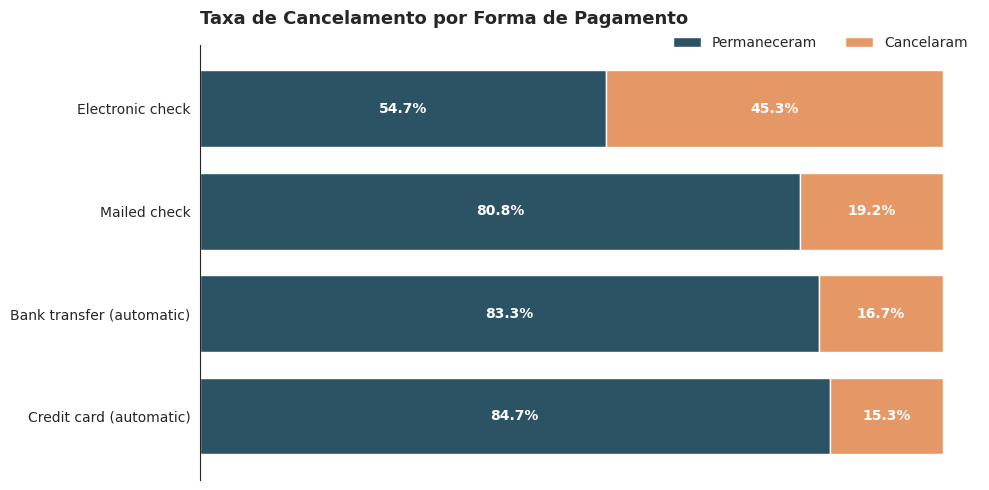

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CONFIGURAÇÕES (Padrão Unificado)
COR_PERMANECEU, COR_CANCELOU = '#2C5364', '#E59866'
sns.set_style("white")

# 2. PREPARAR DADOS
# Tabela cruzada normalizada por índice
pagamento_churn = pd.crosstab(df['Forma_Pagamento'], df['Cancelamento'], normalize='index') * 100

# Ordenação dinâmica pelo percentual de cancelamento
col_churn = pagamento_churn.columns[-1]
pagamento_churn = pagamento_churn.sort_values(by=col_churn, ascending=True)

# 3. VISUALIZAÇÃO
fig, ax = plt.subplots(figsize=(10, 5))

# Plot empilhado
pagamento_churn.plot(kind='barh', stacked=True, ax=ax, color=[COR_PERMANECEU, COR_CANCELOU], width=0.75)

# Título e Legenda
ax.set_title('Taxa de Cancelamento por Forma de Pagamento', fontsize=13, fontweight='bold', loc='left', pad=15)
ax.legend(['Permaneceram', 'Cancelaram'], bbox_to_anchor=(1, 1.05), ncol=2, frameon=False)

# 4. ADICIONAR PERCENTUAIS DENTRO DAS BARRAS
for i in range(len(pagamento_churn)):
    # Fatia: Permaneceram
    val_permaneceu = pagamento_churn.iloc[i, 0]
    ax.text(val_permaneceu/2, i, f'{val_permaneceu:.1f}%',
            va='center', ha='center', color='white', fontweight='bold', fontsize=10)

    # Fatia: Cancelaram
    val_cancelou = pagamento_churn.iloc[i, 1]
    if val_cancelou > 5: # Exibe apenas se houver espaço na barra
        ax.text(val_permaneceu + (val_cancelou/2), i, f'{val_cancelou:.1f}%',
                va='center', ha='center', color='white', fontweight='bold', fontsize=10)

# 5. LIMPEZA (Padrão Unificado: sem bordas e sem eixos)
ax.set_xticks([])
ax.set_ylabel('')
ax.set_xlabel('')
sns.despine(ax=ax, bottom=True)

plt.tight_layout()
plt.show()

**Principais Observações:**

- **Electronic check apresenta taxa alarmante de cancelamento:** 45,3% dos clientes que pagam via cheque eletrônico cancelaram, muito superior às outras formas
- Métodos automáticos (Bank transfer e Credit card) têm taxas significativamente menores: 16,7% e 15,2% respectivamente
- Mailed check possui taxa intermediária de 19,1%
- A facilidade de cancelamento via Electronic check pode estar reduzindo barreiras de saída

➤ **Responde à questão 8:** Sim, o método de pagamento influencia fortemente na decisão de cancelar, com Electronic check sendo um forte indicador de risco

#### 3.4. Evasão por Perfil Demográfico

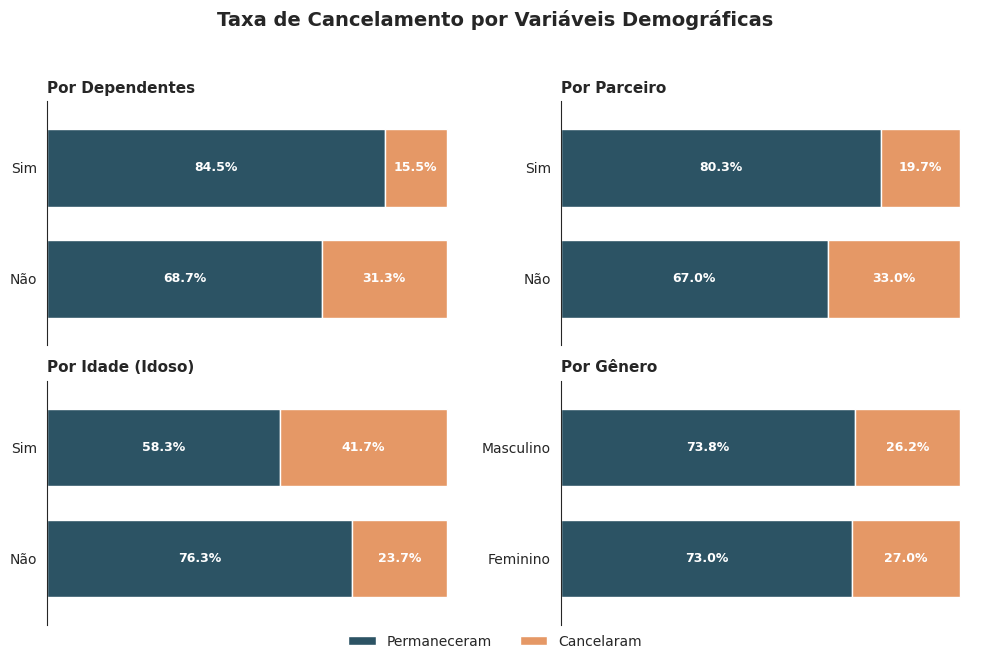

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CONFIGURAÇÕES (Padrão Unificado)
COR_PERMANECEU, COR_CANCELOU = '#2C5364', '#E59866'
sns.set_style("white")

# 2. CONFIGURAÇÃO DO PAINEL
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
fig.suptitle('Taxa de Cancelamento por Variáveis Demográficas', fontsize=14, fontweight='bold', y=0.98)

# Lista de variáveis para o loop
configuracoes = [
    ('Tem_Dependentes', 'Por Dependentes', ['Não', 'Sim']),
    ('Tem_Parceiro', 'Por Parceiro', ['Não', 'Sim']),
    ('Idoso', 'Por Idade (Idoso)', ['Não', 'Sim']),
    ('Genero', 'Por Gênero', ['Feminino', 'Masculino'])
]

# 3. GERAÇÃO DOS GRÁFICOS VIA LOOP
for idx, (var, titulo, labels) in enumerate(configuracoes):
    ax = axes.flat[idx]

    # Tabela cruzada normalizada
    churn_data = pd.crosstab(df[var], df['Cancelamento'], normalize='index') * 100

    # Plot empilhado
    churn_data.plot(kind='barh', stacked=True, ax=ax, color=[COR_PERMANECEU, COR_CANCELOU], width=0.7, legend=False)

    # Estilização de Títulos e Eixos
    ax.set_title(titulo, fontsize=11, fontweight='bold', loc='left')
    ax.set_ylabel('')
    ax.set_yticklabels(labels)
    ax.set_xticks([]) # Remove eixo X

    # Inclusão de rótulos internos
    for i in range(len(churn_data)):
        # Valor Permaneceram
        val_nao = churn_data.iloc[i, 0]
        ax.text(val_nao/2, i, f'{val_nao:.1f}%', va='center', ha='center', color='white', fontweight='bold', fontsize=9)

        # Valor Cancelaram
        val_sim = churn_data.iloc[i, 1]
        if val_sim > 8: # Exibe apenas se a fatia for larga o suficiente
            ax.text(val_nao + (val_sim/2), i, f'{val_sim:.1f}%', va='center', ha='center', color='white', fontweight='bold', fontsize=9)

    # Limpeza visual (Padrão Unificado: sem bordas laterais, superiores e inferiores)
    sns.despine(ax=ax, bottom=True)

# 4. LEGENDA ÚNICA CENTRALIZADA
fig.legend(['Permaneceram', 'Cancelaram'], loc='lower center', bbox_to_anchor=(0.5, 0.05),
           ncol=2, frameon=False, fontsize=10)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()

**Principais Observações:**

**Clientes sem dependentes apresentam taxa significativamente maior de cancelamento**: 31,3% cancelaram, comparado a apenas 15,5% dos que possuem dependentes

**Clientes sem parceiro também cancelam mais**: 33,0% contra 19,7% dos que têm parceiro, indicando que vínculos familiares estão associados a maior retenção

**Idosos apresentam a maior taxa de cancelamento entre todas as variáveis demográficas**: 41,7% cancelaram, comparado a 23,6% dos não idosos, possivelmente por dificuldades de adaptação tecnológica ou maior sensibilidade a preços

**Gênero não é um fator relevante**: Taxas praticamente idênticas entre homens (26,2%) e mulheres (26,9%)

➤ **Responde à questão 4**: Sim, clientes sem dependentes cancelam significativamente mais (31,3% vs 15,5%)

#### 3.5. Evasão por Serviços Adicionais

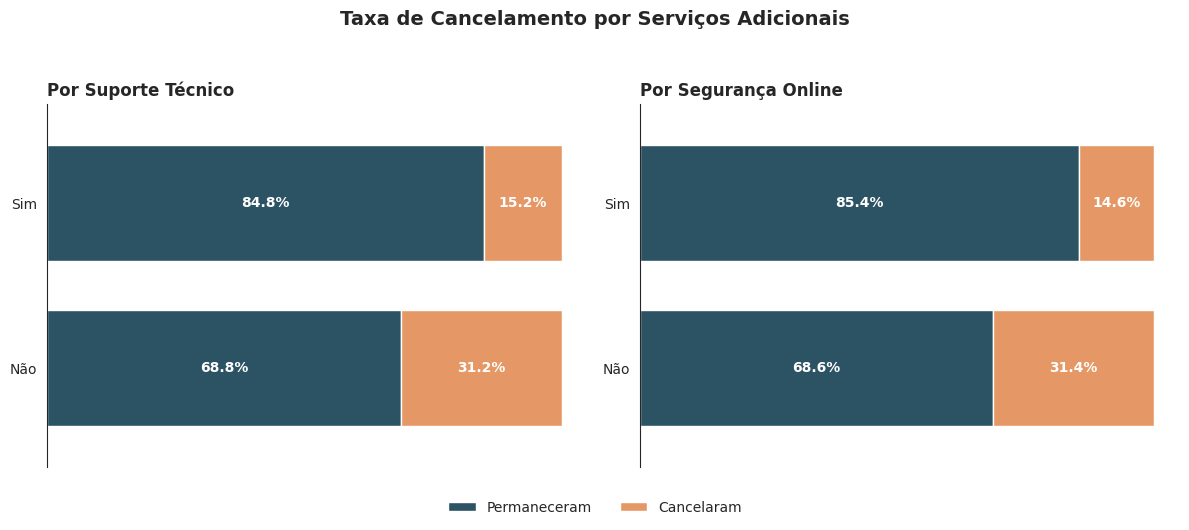

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CONFIGURAÇÕES (Padrão Unificado)
COR_PERMANECEU, COR_CANCELOU = '#2C5364', '#E59866'
sns.set_style("white")

# 2. CONFIGURAÇÃO DO PAINEL
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle('Taxa de Cancelamento por Serviços Adicionais', fontsize=14, fontweight='bold', y=1.05)

# Lista de variáveis para o loop
configuracoes = [
    ('Suporte_Tecnico', 'Por Suporte Técnico', ['Não', 'Sim']),
    ('Seguranca_Online', 'Por Segurança Online', ['Não', 'Sim'])
]

# 3. GERAÇÃO DOS GRÁFICOS VIA LOOP
for idx, (var, titulo, labels) in enumerate(configuracoes):
    ax = axes[idx]

    # Tabela cruzada normalizada
    churn_data = pd.crosstab(df[var], df['Cancelamento'], normalize='index') * 100

    # Plot empilhado (Padrão Unificado)
    churn_data.plot(kind='barh', stacked=True, ax=ax, color=[COR_PERMANECEU, COR_CANCELOU], width=0.7, legend=False)

    # Estilização de Títulos e Eixos
    ax.set_title(titulo, fontsize=12, fontweight='bold', loc='left')
    ax.set_ylabel('')
    ax.set_yticklabels(labels)
    ax.set_xticks([]) # Remove eixo X conforme o padrão

    # Inclusão de rótulos internos (Branco sobre cor sólida)
    for i in range(len(churn_data)):
        # Valor Permaneceram
        val_nao = churn_data.iloc[i, 0]
        ax.text(val_nao/2, i, f'{val_nao:.1f}%', va='center', ha='center', color='white', fontweight='bold', fontsize=10)

        # Valor Cancelaram
        val_sim = churn_data.iloc[i, 1]
        if val_sim > 5:
            ax.text(val_nao + (val_sim/2), i, f'{val_sim:.1f}%', va='center', ha='center', color='white', fontweight='bold', fontsize=10)

    # Limpeza visual (Remoção de bordas conforme o padrão unificado)
    sns.despine(ax=ax, bottom=True)

# 4. LEGENDA ÚNICA CENTRALIZADA
fig.legend(['Permaneceram', 'Cancelaram'], loc='lower center', bbox_to_anchor=(0.5, -0.1),
           ncol=2, frameon=False, fontsize=10)

plt.tight_layout()
plt.show()

**Principais Observações:**

**Clientes sem Suporte Técnico apresentam taxa alarmante de cancelamento**: 41,8% cancelaram, comparado a apenas 15,2% dos que possuem o serviço

**Clientes sem Segurança Online seguem o mesmo padrão crítico**: 41,8% cancelaram, contra apenas 14,6% dos que contrataram o serviço

**Ambos os serviços adicionais apresentam impacto similar na retenção**: A diferença de aproximadamente 27 pontos percentuais em ambos os casos demonstra que a contratação de serviços complementares reduz drasticamente o risco de evasão

**Ausência de serviços adicionais é um dos maiores fatores de risco identificados**: As taxas de ~42% sem os serviços versus ~15% com os serviços representam uma das maiores diferenças observadas em toda a análise

➤ **Responde à questão 5**: Sim, clientes sem serviços adicionais (suporte técnico e segurança online) têm taxa de cancelamento significativamente maior (~42% vs ~15%)

#### 3.6. Síntese da Análise de Evasão por Variáveis Categóricas

**Fatores Críticos de Risco Identificados:**

1. **Tipo de Contrato**: Month-to-month (42,7%) vs contratos anuais (11,3%) e bianuais (2,8%)
2. **Serviços Adicionais**: Sem suporte/segurança (~42%) vs com serviços (~15%)
3. **Forma de Pagamento**: Electronic check (45,3%) vs métodos automáticos (~15-17%)
4. **Tipo de Internet**: Fibra Óptica (41,9%) vs DSL (19,0%)
5. **Perfil Demográfico**: Sem dependentes (31,3%), sem parceiro (33,0%), idosos (41,7%)

**Perfil de Alto Risco Consolidado:**

Cliente com maior probabilidade de cancelamento:
- Contrato mensal (Month-to-month)
- Pagamento via Electronic check
- Internet Fibra Óptica
- Sem Suporte Técnico e sem Segurança Online
- Sem dependentes, sem parceiro ou idoso

Este perfil combina os principais fatores de risco identificados e deve ser priorizado em estratégias de retenção.

**Questões Respondidas Nesta Análise:**

4. ➤ **Clientes sem dependentes cancelam mais?** Sim, 31,3% cancelam vs 15,5% dos que têm dependentes
5. ➤ **Clientes sem serviços adicionais têm maior taxa de cancelamento?** Sim, ~42% cancelam vs ~15% dos que possuem
6. ➤ **Existe correlação entre tipo de contrato e taxa de cancelamento?** Sim, contratos mensais têm 42,7% de cancelamento
7. ➤ **O tipo de internet influencia na taxa de cancelamento?** Sim, Fibra Óptica tem 41,9% de cancelamento
8. ➤ **O método de pagamento influencia na decisão de cancelar?** Sim, Electronic check tem 45,3% de cancelamento

**Insights Adicionais Identificados:**

- Gênero não é fator relevante para cancelamento (taxas praticamente idênticas)
- Clientes sem serviço de internet têm maior retenção (7,4% de cancelamento)
- Idosos apresentam uma das maiores taxas de evasão (41,7%), possivelmente por dificuldades tecnológicas
- Métodos de pagamento automáticos têm desempenho similar e superior (~15-17% de cancelamento)

**Próximos Passos:**

As análises seguintes irão investigar as relações entre variáveis numéricas (tempo de contrato, cobranças) e o comportamento de cancelamento, respondendo às questões 1, 2 e 3 sobre período crítico de evasão e relação entre valores cobrados e taxa de cancelamento.

### 4: Contagem de Evasão por Variáveis Numéricas

Investigação de como variáveis numéricas, como tempo de contrato (tenure), valor total gasto e cobranças mensais, se distribuem entre clientes que cancelaram e os que permaneceram.

**Objetivo:**
Entender se certos valores numéricos estão mais associados à evasão, oferecendo insights sobre os fatores financeiros e temporais que influenciam o comportamento dos clientes.

#### 4.1. Evasão por Tempo de Contrato

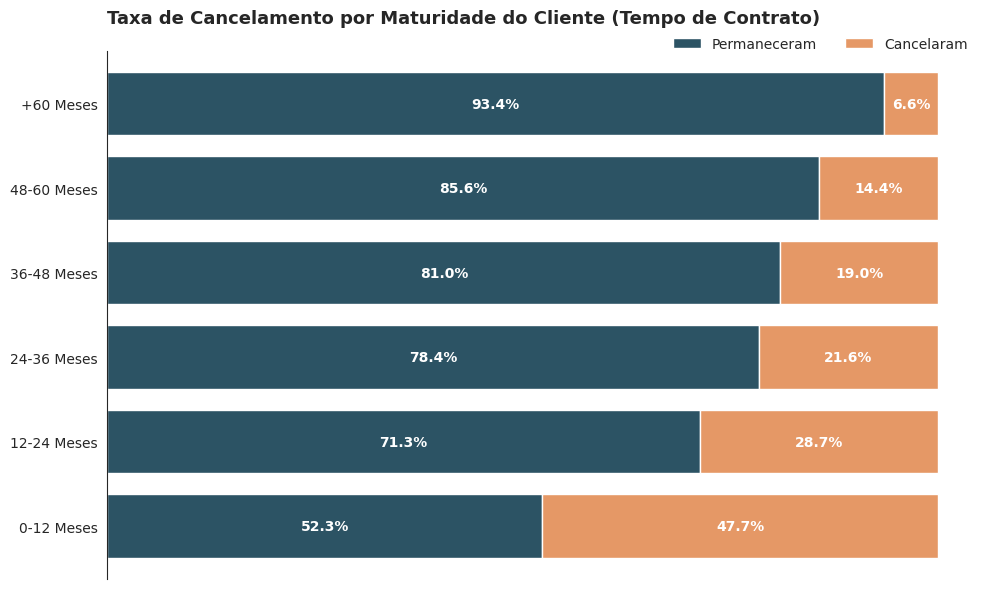

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CONFIGURAÇÕES (Padrão Unificado)
COR_PERMANECEU, COR_CANCELOU = '#2C5364', '#E59866'
sns.set_style("white")

# 2. PREPARAR DADOS
# Criação das faixas (Binning)
bins = [0, 12, 24, 36, 48, 60, 72]
labels = ['0-12 Meses', '12-24 Meses', '24-36 Meses', '36-48 Meses', '48-60 Meses', '+60 Meses']
df['Faixa_Contrato'] = pd.cut(df['Meses_Contrato'], bins=bins, labels=labels)

# Tabela cruzada normalizada
tempo_churn = pd.crosstab(df['Faixa_Contrato'], df['Cancelamento'], normalize='index') * 100

# 3. VISUALIZAÇÃO
fig, ax = plt.subplots(figsize=(10, 6))

# Plot empilhado (Stacked 100%)
tempo_churn.plot(kind='barh', stacked=True, ax=ax, color=[COR_PERMANECEU, COR_CANCELOU], width=0.75)

# Título e Legenda
ax.set_title('Taxa de Cancelamento por Maturidade do Cliente (Tempo de Contrato)', fontsize=13, fontweight='bold', loc='left', pad=20)
ax.legend(['Permaneceram', 'Cancelaram'], bbox_to_anchor=(1, 1.05), ncol=2, frameon=False)

# 4. ADICIONAR PERCENTUAIS DENTRO DAS BARRAS
for i in range(len(tempo_churn)):
    # Valor: Permaneceram
    val_permaneceu = tempo_churn.iloc[i, 0]
    ax.text(val_permaneceu/2, i, f'{val_permaneceu:.1f}%',
            va='center', ha='center', color='white', fontweight='bold', fontsize=10)

    # Valor: Cancelaram
    val_cancelou = tempo_churn.iloc[i, 1]
    if val_cancelou > 3: # Exibe apenas se houver espaço mínimo na barra
        ax.text(val_permaneceu + (val_cancelou/2), i, f'{val_cancelou:.1f}%',
                va='center', ha='center', color='white', fontweight='bold', fontsize=10)

# 5. LIMPEZA FINAL (Padrão Unificado: sem bordas e sem eixos redundantes)
ax.set_xticks([])
ax.set_ylabel('')
ax.set_xlabel('')
sns.despine(ax=ax, bottom=True)

plt.tight_layout()
plt.savefig('tempo_churn.png', bbox_inches='tight', dpi=300)
plt.show()

**Principais Observações:**

**Período crítico identificado: primeiros 12 meses apresentam taxa alarmante de cancelamento**: 47,7% dos clientes com 0-12 meses de contrato cancelaram, a maior taxa observada em todas as faixas

**Taxa de cancelamento diminui progressivamente com o tempo de relacionamento**: 12-24 meses (28,7%), 24-36 meses (21,6%), 36-48 meses (19,0%), 48-60 meses (14,4%), e acima de 60 meses apenas 6,6%

**Clientes com mais de 60 meses apresentam altíssima retenção**: Taxa de permanência de 93,4%, demonstrando que a fidelização aumenta significativamente após os primeiros anos

**O primeiro ano é o momento mais vulnerável para evasão**: A diferença de 19 pontos percentuais entre a primeira faixa (47,7%) e a segunda (28,7%) evidencia que superar os 12 meses iniciais é crítico para a retenção

➤ **Responde à questão 1**: O período crítico onde ocorrem mais cancelamentos são os **primeiros 12 meses de contrato (47,7% de taxa de cancelamento)**

#### 4.2. Evasão por Cobrança Mensal

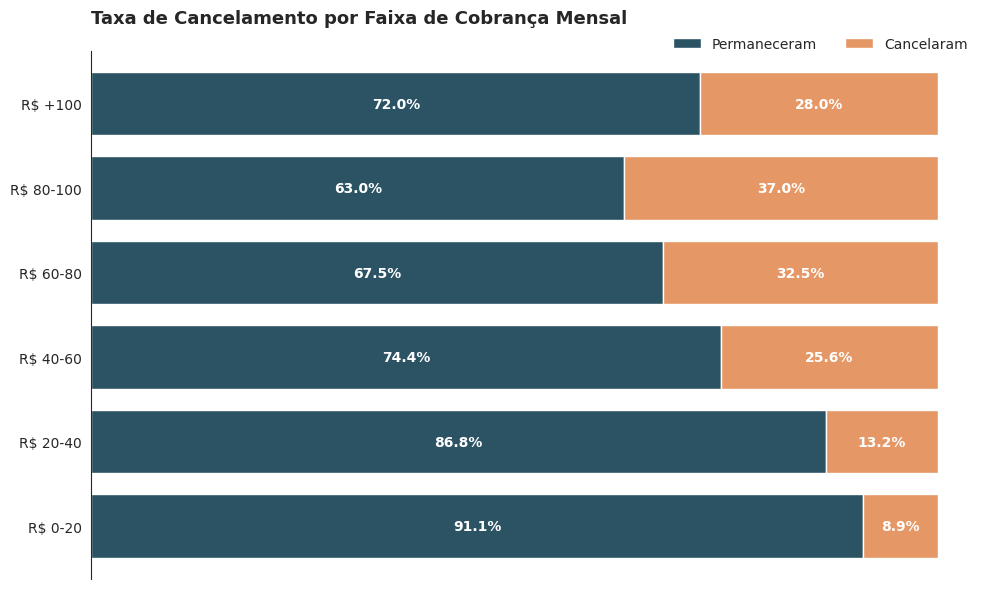

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CONFIGURAÇÕES (Padrão Unificado)
COR_PERMANECEU, COR_CANCELOU = '#2C5364', '#E59866'
sns.set_style("white")

# 2. PREPARAR DADOS (Binning e Crosstab)
bins = [0, 20, 40, 60, 80, 100, 120]
labels = ['R$ 0-20', 'R$ 20-40', 'R$ 40-60', 'R$ 60-80', 'R$ 80-100', 'R$ +100']
df['Faixa_Cobranca_Mensal'] = pd.cut(df['Cobranca_Mensal'], bins=bins, labels=labels)

# Tabela cruzada normalizada
cobranca_churn = pd.crosstab(df['Faixa_Cobranca_Mensal'], df['Cancelamento'], normalize='index') * 100

# 3. VISUALIZAÇÃO
fig, ax = plt.subplots(figsize=(10, 6))

# Plot empilhado (Stacked 100%)
cobranca_churn.plot(kind='barh', stacked=True, ax=ax, color=[COR_PERMANECEU, COR_CANCELOU], width=0.75)

# Título e Legenda
ax.set_title('Taxa de Cancelamento por Faixa de Cobrança Mensal', fontsize=13, fontweight='bold', loc='left', pad=20)
ax.legend(['Permaneceram', 'Cancelaram'], bbox_to_anchor=(1, 1.05), ncol=2, frameon=False)

# 4. ADICIONAR PERCENTUAIS DENTRO DAS BARRAS
for i in range(len(cobranca_churn)):
    # Valor: Permaneceram
    val_permaneceu = cobranca_churn.iloc[i, 0]
    ax.text(val_permaneceu/2, i, f'{val_permaneceu:.1f}%',
            va='center', ha='center', color='white', fontweight='bold', fontsize=10)

    # Valor: Cancelaram
    val_cancelou = cobranca_churn.iloc[i, 1]
    if val_cancelou > 3: # Exibe apenas se houver espaço na barra
        ax.text(val_permaneceu + (val_cancelou/2), i, f'{val_cancelou:.1f}%',
                va='center', ha='center', color='white', fontweight='bold', fontsize=10)

# 5. LIMPEZA FINAL (Padrão Unificado: sem bordas e sem eixos redundantes)
ax.set_xticks([])
ax.set_ylabel('')
ax.set_xlabel('')
sns.despine(ax=ax, bottom=True)

plt.tight_layout()
plt.savefig('preco_churn.png', bbox_inches='tight', dpi=300)
plt.show()

**Principais Observações:**

* **Alta evasão em valores altos:** A faixa de 80 a 100 reais atinge a taxa máxima de cancelamento (37,0%).
* **Retenção nos planos básicos:** A faixa de 0 a 20 reais performa melhor, com apenas 8,9% de evasão.
* **Crescimento progressivo:** O cancelamento sobe conforme o preço aumenta: 8,9% > 13,2% > 25,6% > 32,5%.
* **Ponto crítico (40 reais):** A evasão salta de 13,2% para 25,6%. É onde o cliente reavalia o custo-benefício.

---

**Resposta Questão 2:** Sim. Cobranças acima de 40 reais elevam o cancelamento para mais de 25%, com pico entre 80 e 100 reais.

#### 4.3. Evasão por Cobrança Total

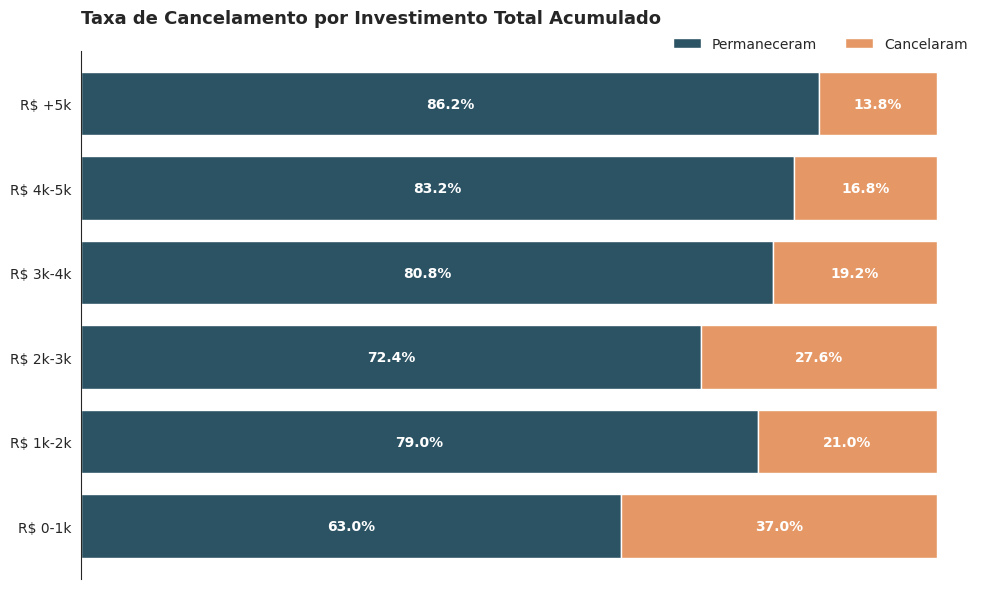

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CONFIGURAÇÕES (Padrão Unificado)
COR_PERMANECEU, COR_CANCELOU = '#2C5364', '#E59866'
sns.set_style("white")

# 2. PREPARAR DADOS (Binning e Crosstab)
bins = [0, 1000, 2000, 3000, 4000, 5000, 10000]
labels = ['R$ 0-1k', 'R$ 1k-2k', 'R$ 2k-3k', 'R$ 3k-4k', 'R$ 4k-5k', 'R$ +5k']
df['Faixa_Cobranca_Total'] = pd.cut(df['Cobranca_Total'], bins=bins, labels=labels)

# Tabela cruzada normalizada
cobranca_total_churn = pd.crosstab(df['Faixa_Cobranca_Total'], df['Cancelamento'], normalize='index') * 100

# 3. VISUALIZAÇÃO
fig, ax = plt.subplots(figsize=(10, 6))

# Plot empilhado (Stacked 100%)
cobranca_total_churn.plot(kind='barh', stacked=True, ax=ax, color=[COR_PERMANECEU, COR_CANCELOU], width=0.75)

# Título e Legenda
ax.set_title('Taxa de Cancelamento por Investimento Total Acumulado', fontsize=13, fontweight='bold', loc='left', pad=20)
ax.legend(['Permaneceram', 'Cancelaram'], bbox_to_anchor=(1, 1.05), ncol=2, frameon=False)

# 4. ADICIONAR PERCENTUAIS DENTRO DAS BARRAS
for i in range(len(cobranca_total_churn)):
    # Valor: Permaneceram
    val_permaneceu = cobranca_total_churn.iloc[i, 0]
    ax.text(val_permaneceu/2, i, f'{val_permaneceu:.1f}%',
            va='center', ha='center', color='white', fontweight='bold', fontsize=10)

    # Valor: Cancelaram
    val_cancelou = cobranca_total_churn.iloc[i, 1]
    if val_cancelou > 3: # Exibe apenas se houver espaço na barra
        ax.text(val_permaneceu + (val_cancelou/2), i, f'{val_cancelou:.1f}%',
                va='center', ha='center', color='white', fontweight='bold', fontsize=10)

# 5. LIMPEZA FINAL (Padrão Unificado: sem bordas e sem eixos)
ax.set_xticks([])
ax.set_ylabel('')
ax.set_xlabel('')
sns.despine(ax=ax, bottom=True)

plt.tight_layout()
plt.show()

**Principais Observações:**

* **Menor gasto, maior evasão:** Clientes na faixa de 0 a 1 mil reais apresentam a maior taxa de cancelamento (37,0%).
* **Investimento gera retenção:** A evasão cai conforme o gasto total acumulado aumenta, reduzindo de 37,0% para 13,8%.
* **Fidelidade em faixas altas:** Gastos acima de 4 mil reais garantem as menores taxas de cancelamento (abaixo de 17%).
* **Anomalia detectada:** A faixa de 2 a 3 mil reais tem um salto para 27,6%, indicando um possível ponto de risco ou transição.
* **Reflexo do tempo:** O gasto total reflete o tempo de contrato; clientes mais antigos acumulam mais investimento e saem menos.

---

**Resposta Questão 3:** Sim. Há uma diferença clara: clientes com baixo gasto (0 a 1 mil) cancelam 37,0%, enquanto clientes com gasto acima de 5 mil cancelam apenas 13,8%.

#### 4.4. Síntese da Análise de Evasão por Variáveis Numéricas

**Fatores Críticos de Risco Identificados:**

1. **Tempo de Contrato**: Clientes novos (0-12 meses) apresentam taxa de cancelamento significativamente maior, com redução progressiva conforme aumenta o tempo de relacionamento
2. **Cobrança Mensal**: Valores acima de 40 reais apresentam taxas superiores a 25%, com pico de 37,0% na faixa de 80 a 100 reais
3. **Cobrança Total**: Clientes com menor gasto acumulado (0-1k) têm taxa de 37,0%, reduzindo para 13,8% em gastos superiores a 5 mil reais

**Padrões Identificados:**

- **Período Crítico de Retenção**: Os primeiros 12 meses são decisivos para a permanência do cliente, representando a fase de maior vulnerabilidade à evasão
- **Sensibilidade a Preço**: Existe uma correlação direta entre valor cobrado mensalmente e taxa de cancelamento, principalmente acima de 40 reais
- **Vínculo pelo Investimento**: Clientes com maior tempo de relacionamento e gasto acumulado apresentam menor propensão ao cancelamento, indicando que o histórico financeiro gera compromisso
- **Polarização de Valores**: A concentração em planos básicos (aproximadamente 20 reais) e completos (70-100 reais) sem opções intermediárias pode contribuir para a alta evasão em faixas superiores

**Questões Respondidas Nesta Análise:**

1. **➤ Qual o período crítico onde ocorrem mais cancelamentos?** Os primeiros 12 meses de contrato representam o período de maior risco de evasão
2. **➤ Existe relação entre valor cobrado e taxa de evasão?** Sim, cobranças mensais acima de 40 reais apresentam taxas de cancelamento superiores a 25%
3. **➤ Há diferença na taxa de cancelamento entre planos básicos e completos?** Sim, planos mais caros (acima de 60 reais) têm taxas de cancelamento superiores a 32%, enquanto planos básicos (0-20 reais) têm apenas 8,9%

**Próximos Passos:**

A análise consolidada de todas as variáveis (categóricas e numéricas) permitirá identificar o perfil completo de alto risco e direcionar estratégias de retenção mais eficazes para os segmentos críticos identificados.

### 5: Análise de Correlação entre Variáveis

Investigação das relações matemáticas entre variáveis numéricas e categóricas para identificar padrões de associação que influenciam o comportamento de evasão.

**Objetivo:** Compreender como diferentes características dos clientes se relacionam entre si e com a decisão de cancelamento, revelando combinações de fatores que aumentam o risco de evasão e direcionando estratégias de retenção mais eficazes.

#### 5.1. Matriz de Correlação Geral

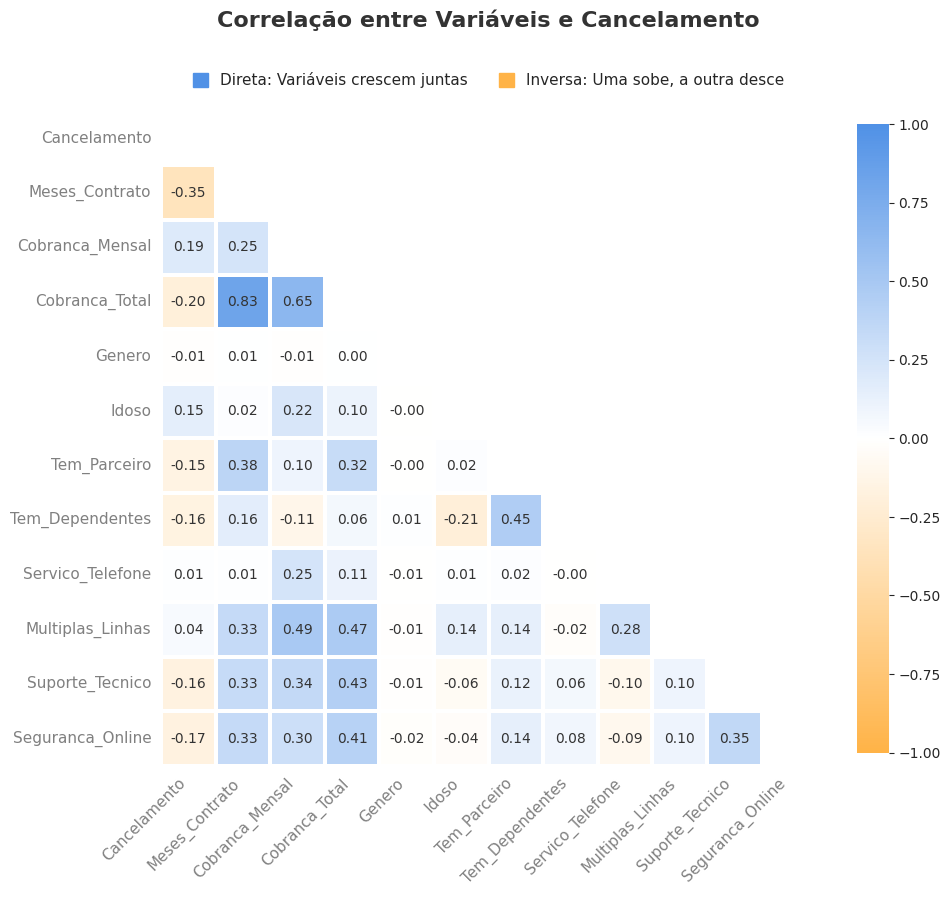

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

# --- 1. CONFIGURAÇÕES INICIAIS ---
# Definimos a cor principal caso ela não tenha sido definida anteriormente
COR_PRINCIPAL = '#5091e6' # Tom de azul da sua imagem de referência

# --- 2. PREPARAÇÃO DOS DADOS ---
# Seleção das colunas conforme seu código funcional
colunas_selecionadas = [
    'Cancelamento', 'Meses_Contrato', 'Cobranca_Mensal', 'Cobranca_Total',
    'Genero', 'Idoso', 'Tem_Parceiro', 'Tem_Dependentes',
    'Servico_Telefone', 'Multiplas_Linhas', 'Suporte_Tecnico', 'Seguranca_Online'
]

# Cálculo da matriz de correlação (Assume que o DataFrame 'df' existe)
try:
    df_numeric = df[colunas_selecionadas]
    matriz_corr = df_numeric.corr()
except NameError:
    print("Erro: O DataFrame 'df' não foi encontrado. Certifique-se de carregar seus dados antes.")
    # Criando dados fictícios apenas para demonstração se o df não existir
    matriz_corr = None

if matriz_corr is not None:
    # --- 3. CONFIGURAÇÃO VISUAL ---
    fig, ax = plt.subplots(figsize=(10, 10))

    # Máscara para o triângulo superior
    mask = np.triu(np.ones_like(matriz_corr, dtype=bool))

    # Paleta de cores personalizada (Laranja -> Branco -> Azul)
    cmap_personalizado = LinearSegmentedColormap.from_list(
        'OrangeBlue', ['#FFB347', '#ffffff', COR_PRINCIPAL], N=256
    )

    # --- 4. PLOTAGEM DO HEATMAP ---
    sns.heatmap(
        matriz_corr,
        mask=mask,
        annot=True,
        fmt='.2f',
        cmap=cmap_personalizado,
        center=0,
        vmin=-1, vmax=1,
        square=True,
        linewidths=1.5, # Bordas brancas entre os quadrados
        cbar_kws={"shrink": 0.7}, # Barra lateral (será escondida ou ajustada)
        ax=ax,
        annot_kws={"size": 10, "color": "#333333"} # Estilo dos números
    )

    # --- 5. TÍTULO E LEGENDA (ESTILO DA IMAGEM) ---

    # Título centralizado e em negrito
    plt.title('Correlação entre Variáveis e Cancelamento',
              fontsize=16, fontweight='bold', color='#333333', pad=60)

    # Legenda Personalizada (Patches quadrados)
    legenda_azul = mpatches.Patch(color=COR_PRINCIPAL, label='Direta: Variáveis crescem juntas')
    legenda_laranja = mpatches.Patch(color='#FFB347', label='Inversa: Uma sobe, a outra desce')

    ax.legend(handles=[legenda_azul, legenda_laranja],
              loc='upper center',
              bbox_to_anchor=(0.5, 1.08), # Posicionamento exato acima do gráfico
              ncol=2,
              frameon=False,
              fontsize=11,
              handlelength=1,
              handleheight=1)

    # --- 6. ESTILIZAÇÃO DOS EIXOS E LIMPEZA ---

    # Rotação e cor dos rótulos
    plt.xticks(rotation=45, ha='right', fontsize=11, color='gray')
    plt.yticks(rotation=0, fontsize=11, color='gray')

    # Remove molduras e ticks
    ax.set_frame_on(False)
    ax.tick_params(left=False, bottom=False)
    ax.grid(False)

    plt.tight_layout()
    plt.show()


**Principais Observações:**

**Fatores Mais Relevantes para Cancelamento (ordenados por força):**

1. **Meses_Contrato (-0.35):** Fator mais forte. Quanto maior o tempo de relacionamento, menor o risco de cancelamento. Confirma que os primeiros meses são críticos.

2. **Cobrança_Total (-0.20):** Clientes com maior investimento acumulado (alto LTV) cancelam menos. O histórico financeiro gera compromisso.

3. **Cobrança_Mensal (+0.19):** Principal fator de atrito. Valores mensais altos aumentam o risco de saída, evidenciando sensibilidade a preço.

4. **Serviços Adicionais (-0.17 e -0.16):** Segurança Online e Suporte Técnico têm impacto similar. Clientes com serviços extras são mais fiéis que os de planos básicos.

5. **Perfil Familiar (-0.16 e -0.15):** Clientes com Dependentes ou Parceiro cancelam menos. Estrutura familiar indica estabilidade.

6. **Idoso (+0.15):** Clientes idosos apresentam maior risco de cancelamento.

**Insight Central - Paradoxo da Cobrança:**
A fidelidade (tempo) é a âncora mais forte de retenção (-0.35), enquanto o preço mensal alto é o maior motivador de saída (+0.19). Porém, o investimento total acumulado reduz o cancelamento (-0.20): preços altos geram resistência imediata, mas o histórico de gastos cria vínculo ao longo do tempo.

#### 5.2. Perfis de Risco: Cobrança Mensal vs. Tempo de Contrato



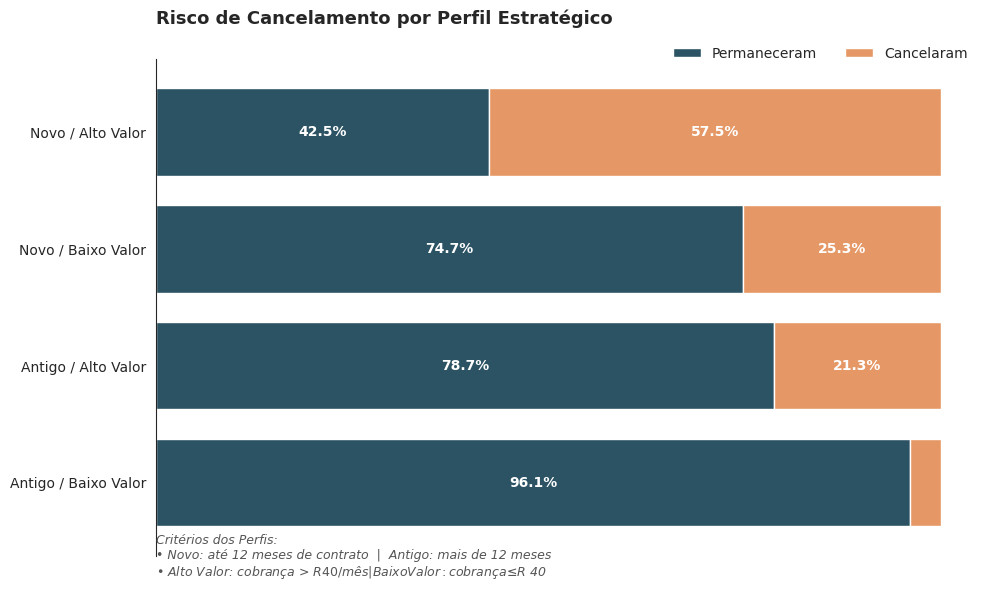

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CONFIGURAÇÕES (Padrão Unificado)
COR_PERMANECEU, COR_CANCELOU = '#2C5364', '#E59866'
sns.set_style("white")

# 2. PREPARAR DADOS (Lógica de Quadrantes)
def definir_perfil(row):
    # Critérios definidos na análise estratégica
    tempo = 'Novo' if row['Meses_Contrato'] <= 12 else 'Antigo'
    valor = 'Alto Valor' if row['Cobranca_Mensal'] > 40 else 'Baixo Valor'
    return f"{tempo} / {valor}"

df['Perfil_Risco'] = df.apply(definir_perfil, axis=1)

# Tabela cruzada normalizada
perfil_churn = pd.crosstab(df['Perfil_Risco'], df['Cancelamento'], normalize='index') * 100

# Ordenação dinâmica pelo percentual de cancelamento (Churn no topo)
col_churn = perfil_churn.columns[-1]
perfil_churn = perfil_churn.sort_values(by=col_churn, ascending=True)

# 3. VISUALIZAÇÃO
fig, ax = plt.subplots(figsize=(10, 6))

# Plot empilhado
perfil_churn.plot(kind='barh', stacked=True, ax=ax, color=[COR_PERMANECEU, COR_CANCELOU], width=0.75)

# Título e Legenda
ax.set_title('Risco de Cancelamento por Perfil Estratégico', fontsize=13, fontweight='bold', loc='left', pad=25)
ax.legend(['Permaneceram', 'Cancelaram'], bbox_to_anchor=(1, 1.05), ncol=2, frameon=False)

# 4. EXPLICAÇÃO DOS SEGMENTOS (Legenda de apoio)
explicação = (
    "Critérios dos Perfis:\n"
    "• Novo: até 12 meses de contrato  |  Antigo: mais de 12 meses\n"
    "• Alto Valor: cobrança > R$ 40/mês |  Baixo Valor: cobrança ≤ R$ 40"
)
ax.text(0, -0.8, explicação, fontsize=9, color='#555', style='italic', ha='left')

# 5. ADICIONAR PERCENTUAIS DENTRO DAS BARRAS
for i in range(len(perfil_churn)):
    val_permaneceu = perfil_churn.iloc[i, 0]
    ax.text(val_permaneceu/2, i, f'{val_permaneceu:.1f}%',
            va='center', ha='center', color='white', fontweight='bold', fontsize=10)

    val_cancelou = perfil_churn.iloc[i, 1]
    if val_cancelou > 5:
        ax.text(val_permaneceu + (val_cancelou/2), i, f'{val_cancelou:.1f}%',
                va='center', ha='center', color='white', fontweight='bold', fontsize=10)

# 6. LIMPEZA FINAL (Padrão Unificado)
ax.set_xticks([])
ax.set_ylabel('')
ax.set_xlabel('')
sns.despine(ax=ax, bottom=True)

plt.tight_layout()
plt.show()

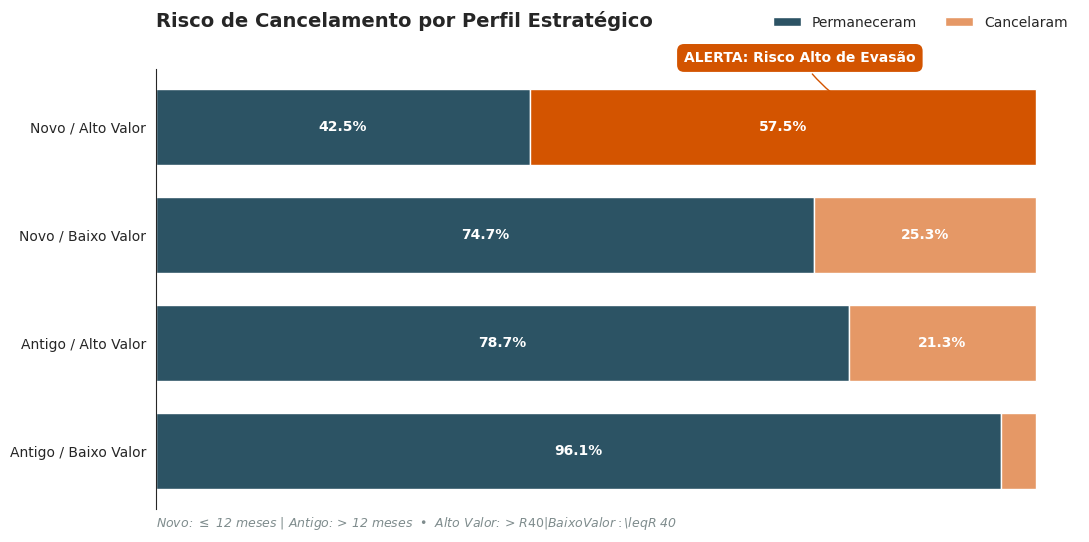

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CONFIGURAÇÕES (Padrão Unificado)
COR_PERMANECEU = '#2C5364'
COR_CANCELOU_BASE = '#E59866'
COR_ALERTA = '#D35400'
sns.set_style("white")

# 2. PREPARAR DADOS
def definir_perfil(row):
    tempo = 'Novo' if row['Meses_Contrato'] <= 12 else 'Antigo'
    valor = 'Alto Valor' if row['Cobranca_Mensal'] > 40 else 'Baixo Valor'
    return f"{tempo} / {valor}"

df['Perfil_Risco'] = df.apply(definir_perfil, axis=1)
perfil_churn = pd.crosstab(df['Perfil_Risco'], df['Cancelamento'], normalize='index') * 100
perfil_churn = perfil_churn.sort_values(by=perfil_churn.columns[-1], ascending=True)

# 3. VISUALIZAÇÃO
fig, ax = plt.subplots(figsize=(11, 5.5))

# Cores dinâmicas para destaque
cores_fatias = [COR_ALERTA if "Novo / Alto Valor" in perfil else COR_CANCELOU_BASE
                for perfil in perfil_churn.index]

ax.barh(perfil_churn.index, perfil_churn.iloc[:, 0], color=COR_PERMANECEU, height=0.7)
ax.barh(perfil_churn.index, perfil_churn.iloc[:, 1], left=perfil_churn.iloc[:, 0],
        color=cores_fatias, height=0.7)

# 4. FRASE CURTA E POSICIONAMENTO DA CAIXINHA
# 'xy' aponta para a barra do topo (index 3), na parte do cancelamento
ax.annotate("ALERTA: Risco Alto de Evasão",
            xy=(85, 3), xytext=(60, 3.6),
            fontsize=10, fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.5', fc=COR_ALERTA, ec='none'),
            arrowprops=dict(arrowstyle='->', connectionstyle="arc3,rad=.2", color=COR_ALERTA))

# 5. TÍTULO E EXPLICAÇÃO (Padrão Unificado)
ax.set_title('Risco de Cancelamento por Perfil Estratégico', fontsize=14, fontweight='bold', loc='left', pad=30)
legenda_criterios = r"Novo: $\leq$ 12 meses | Antigo: > 12 meses  •  Alto Valor: > R$ 40 | Baixo Valor: $\leq$ R$ 40"
ax.text(0, -0.7, legenda_criterios, fontsize=9, color='#7F8C8D', style='italic')

# 6. RÓTULOS INTERNOS
for i in range(len(perfil_churn)):
    p1, p2 = perfil_churn.iloc[i, 0], perfil_churn.iloc[i, 1]
    ax.text(p1/2, i, f'{p1:.1f}%', va='center', ha='center', color='white', fontweight='bold')
    if p2 > 5:
        ax.text(p1 + (p2/2), i, f'{p2:.1f}%', va='center', ha='center', color='white', fontweight='bold')

# 7. LIMPEZA FINAL
ax.legend(['Permaneceram', 'Cancelaram'], loc='upper right', bbox_to_anchor=(1, 1.15), ncol=2, frameon=False)
ax.set_xticks([])
ax.set_ylabel('')
sns.despine(ax=ax, bottom=True)

plt.tight_layout()
plt.savefig('perfil_risco.png', bbox_inches='tight', dpi=300)
plt.show()

**Principais Observações:**

Novo / Alto Valor (Risco Máximo): O preço elevado sem o amortecedor da fidelidade gera rejeição imediata. É o ponto focal de perda de receita.

Antigo / Alto Valor (Resiliência): A queda abrupta do cancelamento neste grupo prova que a sensibilidade ao preço desaparece com o tempo. O cliente se adapta ao custo.

Baixo Valor (Colchão de Segurança): O ticket baixo sustenta a retenção mesmo sem vínculo emocional (Novos). O preço acessível é, isoladamente, a maior barreira de saída.

**Insight Central** - A Curva de Tolerância: O preço alto é tóxico apenas na fase de aquisição (primeiro ano). Após os 12 meses, a maturidade do contrato anula a objeção ao custo, transformando o perfil mais volátil (caro e novo) no ativo mais valioso (caro e fiel).

#### 5.3. Síntese da Análise de Correlação

**Análise Integrada**
- O Filtro Temporal do Preço: A sensibilidade ao custo (+0.19) é um fenômeno de curto prazo. O tempo de contrato (-0.35) atua como um "amortecedor": quanto mais meses o cliente permanece, mais ele se torna imune ao preço alto. O risco não está no valor da conta, mas na ausência de histórico para justificá-lo.

- A Blindagem pelo Investimento (LTV): A correlação negativa da Cobrança Total (-0.20) explica por que clientes "Antigos / Alto Valor" permanecem. O investimento acumulado cria uma "barreira de saída psicológica": o cliente percebe que já investiu demais para abandonar os benefícios e a estabilidade conquistada.

- Serviços como Camadas de Adesão: Serviços extras (-0.17) e estrutura familiar (-0.16) funcionam como nós de uma rede. Eles aumentam a complexidade do cancelamento, transformando um serviço utilitário em uma necessidade integrada ao cotidiano da família.

**Conclusão Estratégica**: O churn nesta base é um problema de maturação. O preço alto é o gatilho, mas a falta de tempo é a causa raiz. A empresa não precisa baixar preços para todos; precisa subsidiar o primeiro ano dos clientes de alto valor. Uma vez superada a barreira dos 12 meses, o próprio histórico financeiro e os serviços adicionais garantem a retenção automática, independentemente do ticket mensal.

# 📄 Relatório Final: Análise de Churn e Estratégias de Retenção – Telecom X

### 1: Introdução





Este relatório apresenta os resultados da análise de evasão de clientes (churn) da **Telecom X**. O churn é um indicador crítico que mede a taxa de cancelamento; no setor de telecomunicações, compreender esse fenômeno é vital, pois o **custo de aquisição de um novo cliente (CAC)** é significativamente superior ao custo de manutenção da base atual.

A análise evidencia que a maior hemorragia financeira concentra-se em **clientes novos e de alto valor**, que cancelam o serviço antes de a empresa recuperar o investimento de aquisição. O objetivo do projeto é **transformar dados brutos em inteligência de negócio**, identificando os gatilhos que levam à saída e propondo **estratégias de retenção focadas nesse segmento**.

### 2: Limpeza e Tratamento de Dados




Para garantir a precisão estatística, os dados passaram por um pipeline de **ETL (Extração, Transformação e Carga)**:

* **Extração:** Os dados foram consumidos via API em formato JSON.  
* **Normalização (Flattening):** Como os dados brutos continham estruturas aninhadas (`customer`, `phone`, `internet`, `account`), realizou-se o desaninhamento dessas chaves para criar um DataFrame tabular.  
* **Tratamento de Tipos:** Variáveis financeiras e de consumo foram convertidas de `string/object` para `float64`, permitindo cálculos de média e correlação.  
* **Sanitização:** Valores nulos foram tratados e categorias padronizadas, garantindo ausência de viés decorrente de dados faltantes.  

Esse processo assegurou que as análises exploratórias refletissem comportamentos reais da base de clientes.

### 3: Análise Exploratória de Dados (EDA)




A análise exploratória revelou padrões comportamentais consistentes na base de clientes, que orientam diretamente as conclusões e recomendações de negócio apresentadas a seguir.




#### 3.1 Impacto do Ciclo de Vida: churn concentrado em até 12 meses

A análise temporal mostra que o churn da **Telecom X** é, sobretudo, um problema de maturação do relacionamento:

* **Janela crítica:** Clientes com menos de 12 meses concentram a maior parte dos cancelamentos.  
* **Barreira psicológica de permanência:** Após o primeiro ano, a taxa de evasão cai drasticamente, sugerindo fidelização natural e maior custo psicológico de troca.  
* **Comportamento volátil:** Clientes novos demonstram menor tolerância a falhas técnicas e maior sensibilidade à concorrência.




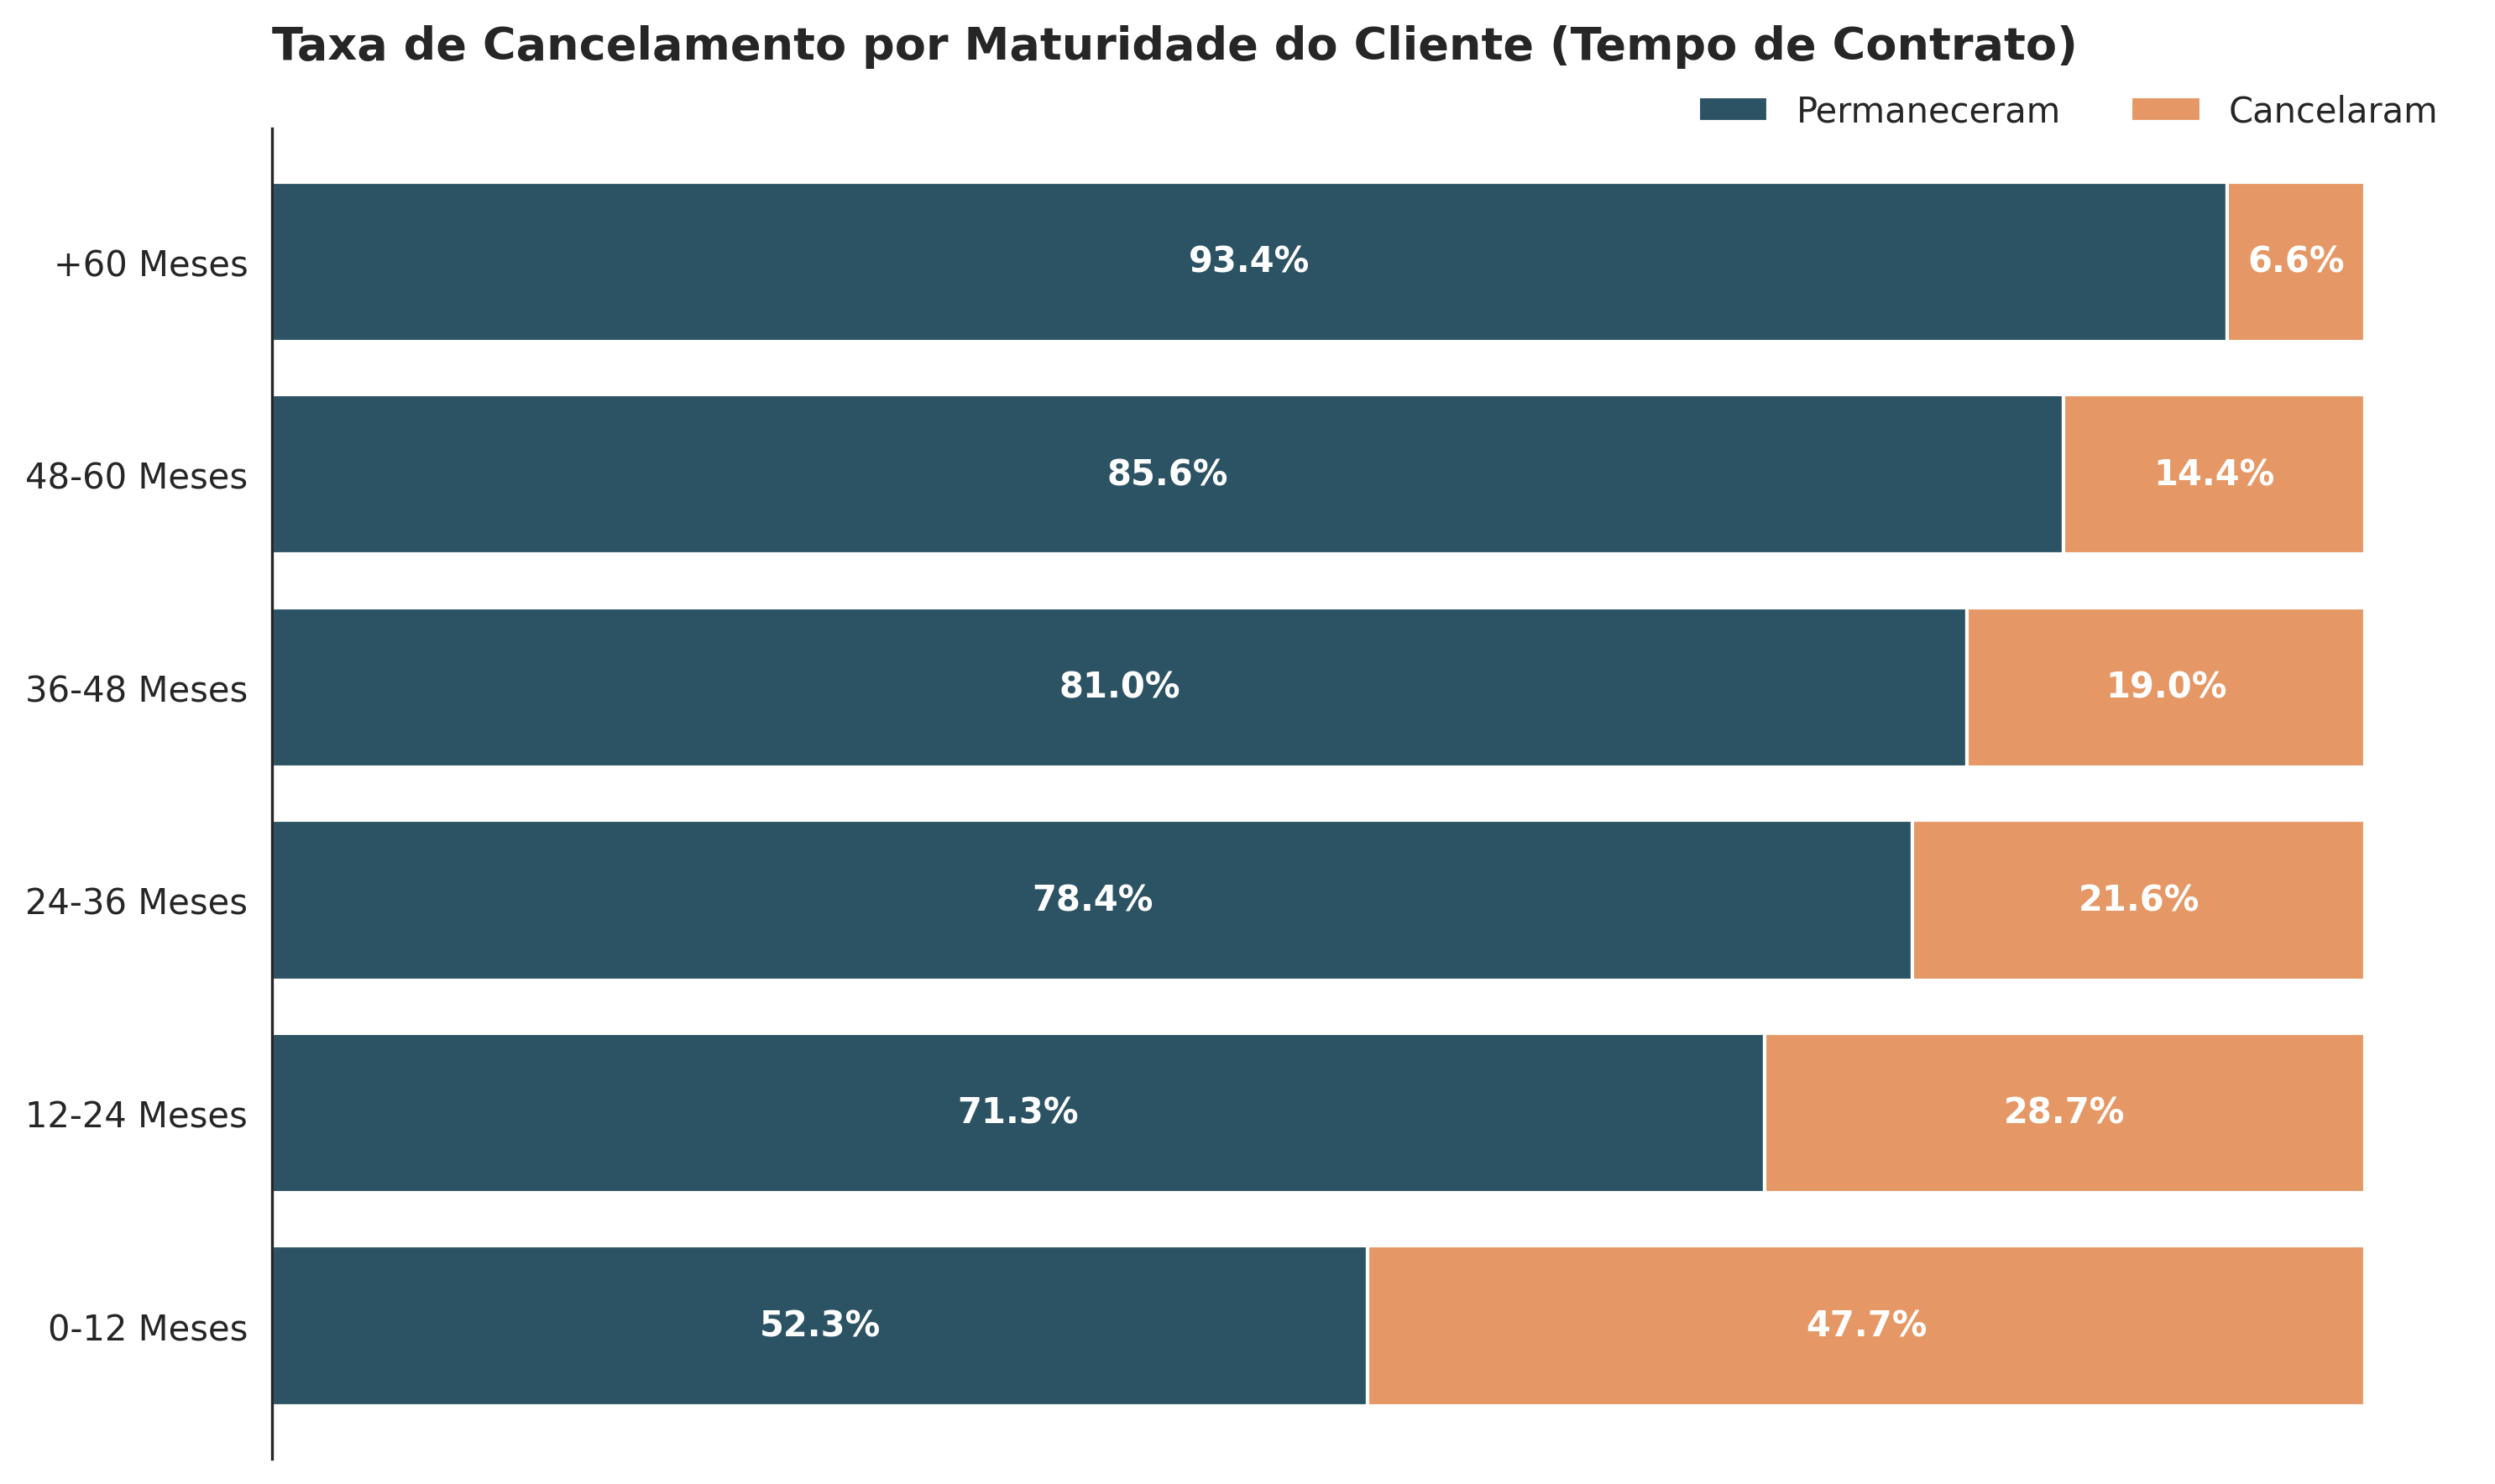

In [106]:
from IPython.display import Image
Image('/content/tempo_churn.png', width=700)


#### 3.2 Sensibilidade ao Preço: salto de churn acima de R$ 60

A precificação atua como **gatilho imediato** para o cancelamento, sobretudo em serviços de maior valor:

* **Ponto de inflexão:** Observa-se aumento expressivo no churn quando a mensalidade ultrapassa o patamar de R$ 60,00.  
* **Faixas críticas:** Clientes em faixas de preço mais altas (R$ 80–R$ 120) exibem propensão elevada à evasão.  
* **Percepção de valor:** Na ausência de contrapartidas tangíveis (benefícios, diferenciação de serviço), o valor elevado é racionalizado pelo cliente como motivo para cancelamento.




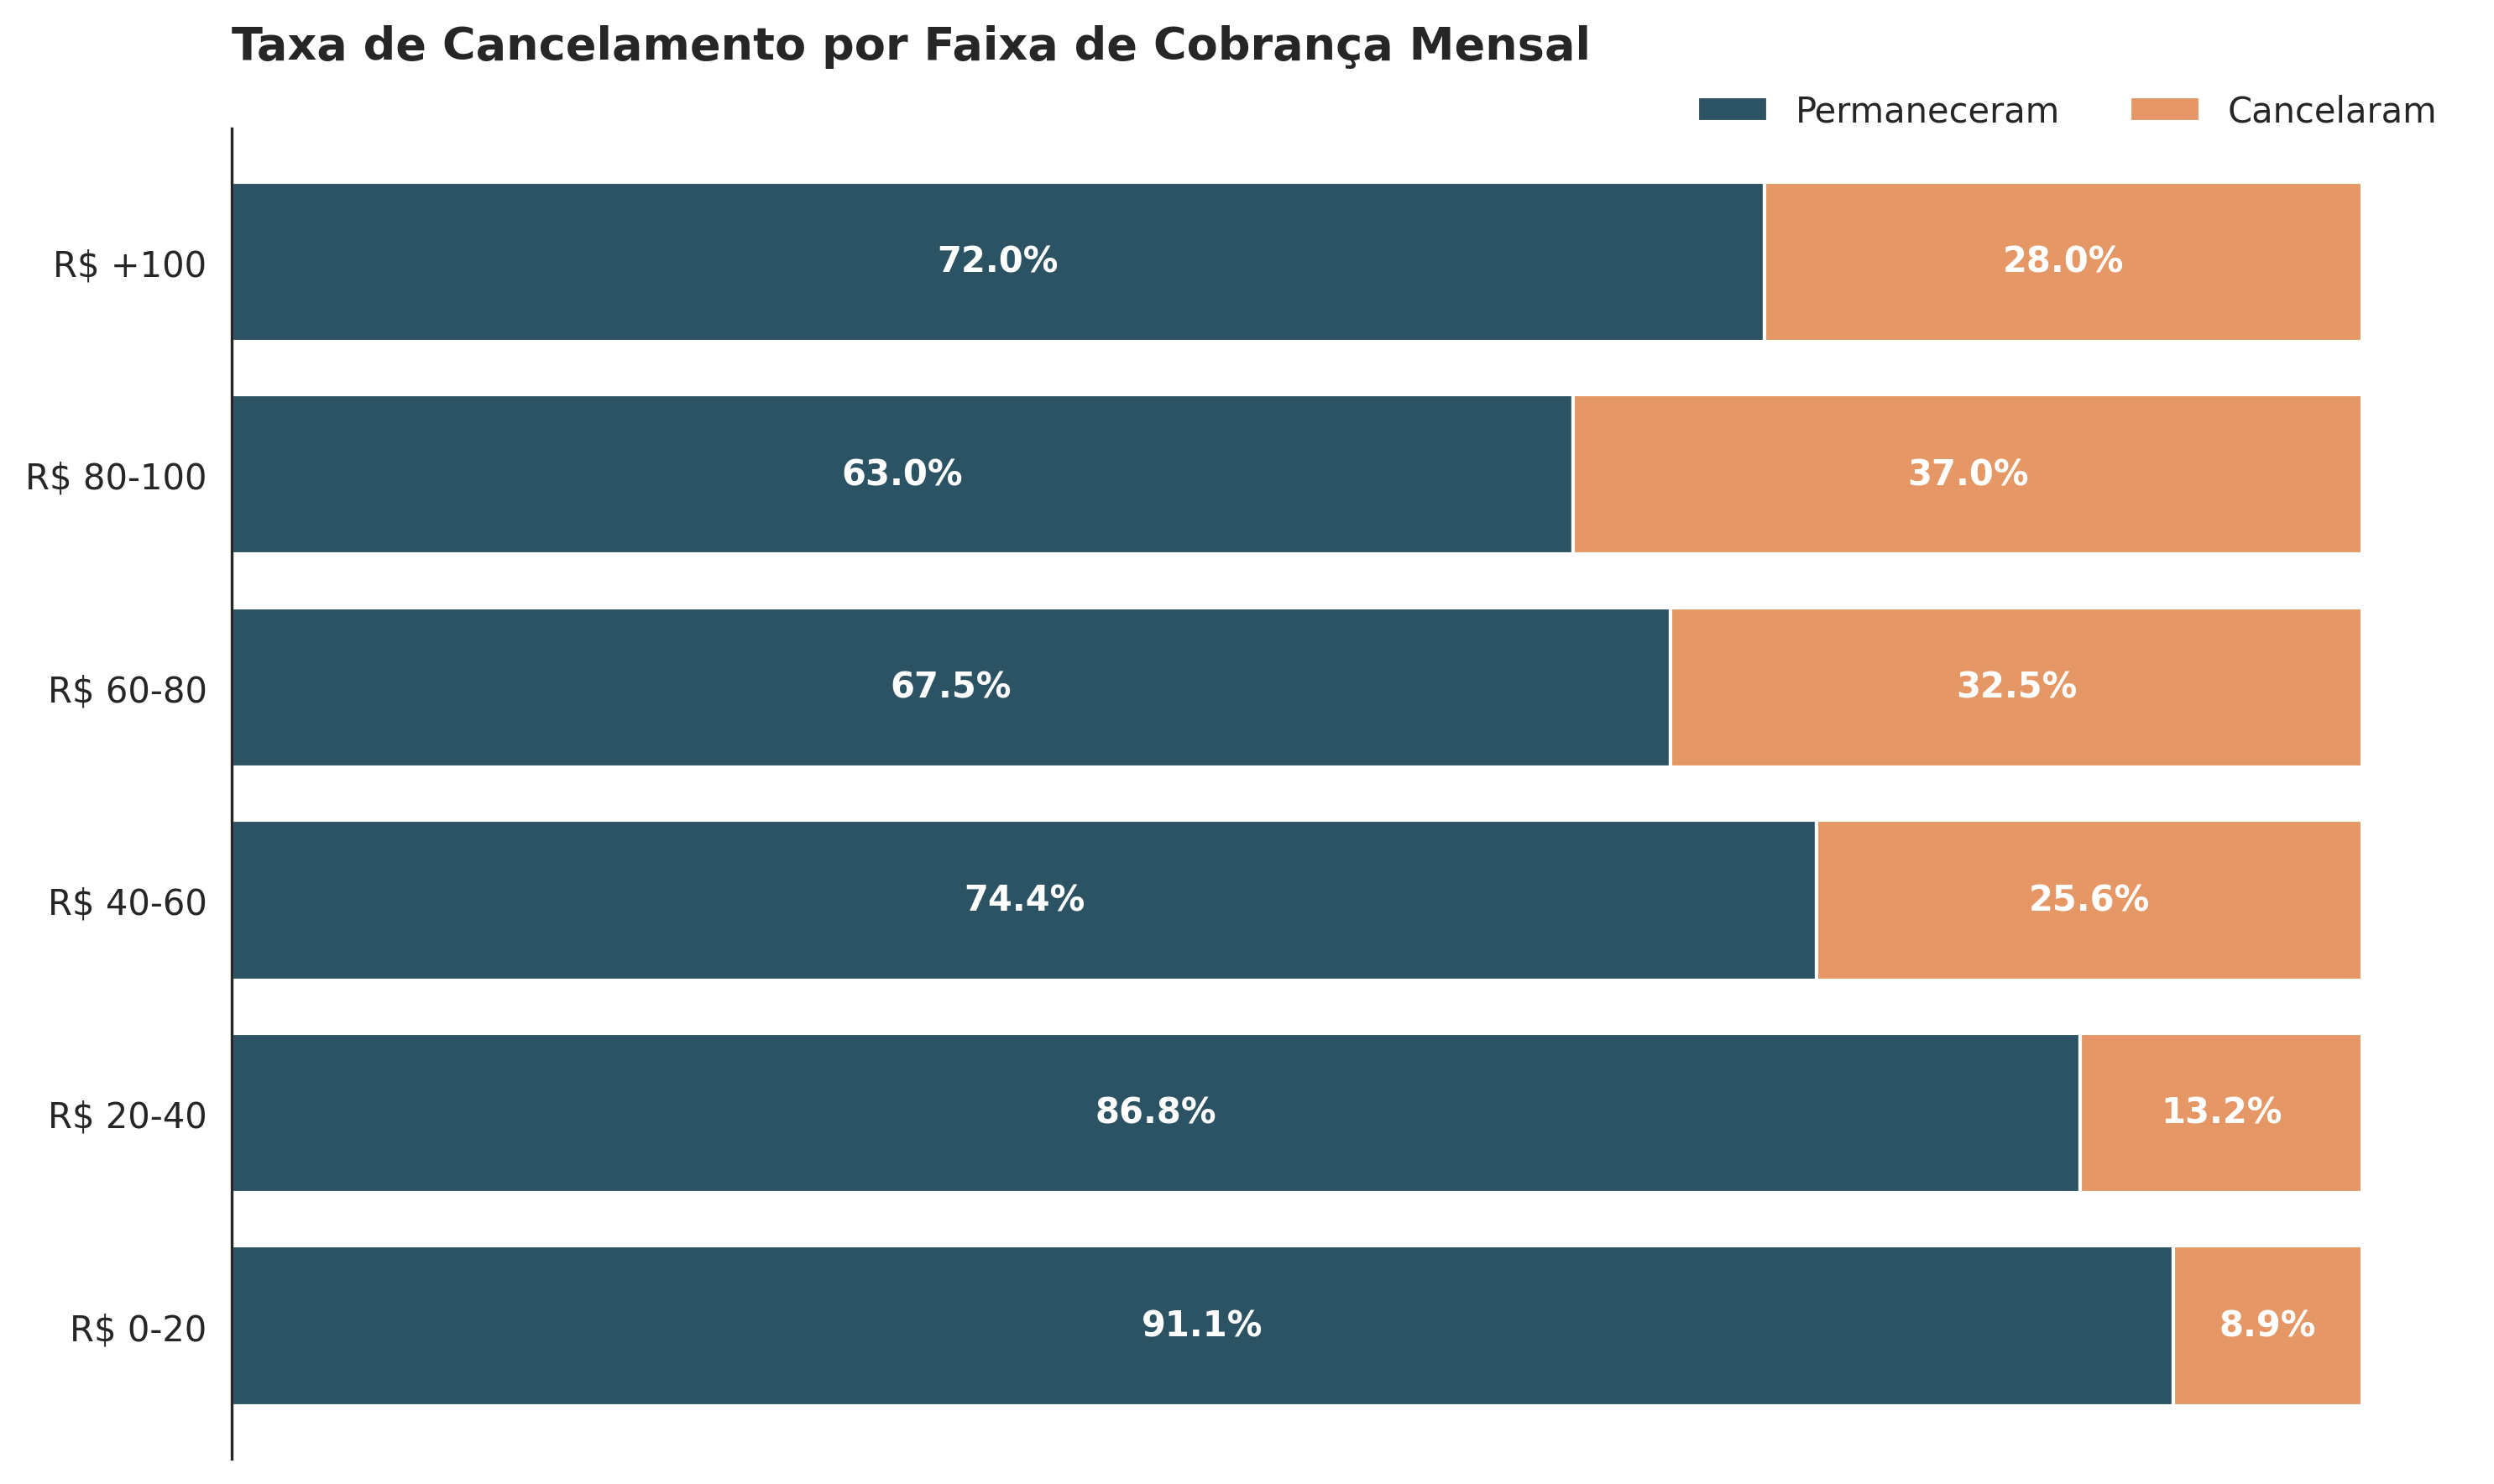

In [107]:
from IPython.display import Image
Image('/content/preco_churn.png', width=700)


#### 3.3 Quadrante Crítico: clientes novos e de alto valor

O cruzamento entre tempo de relacionamento e valor da fatura identifica o grupo de **maior risco financeiro** para a operação:

* **Segmento “Novo / Alto Valor”:** Clientes com até 12 meses e fatura acima de R$ 40 apresentam a maior taxa de churn da empresa.  
* **Impacto no CAC:** Esse grupo tende a cancelar antes do retorno do investimento de aquisição.  
* **Prioridade gerencial:** A retenção deve concentrar esforços nesse quadrante, combinando incentivos financeiros e acompanhamento proativo durante o primeiro ano.



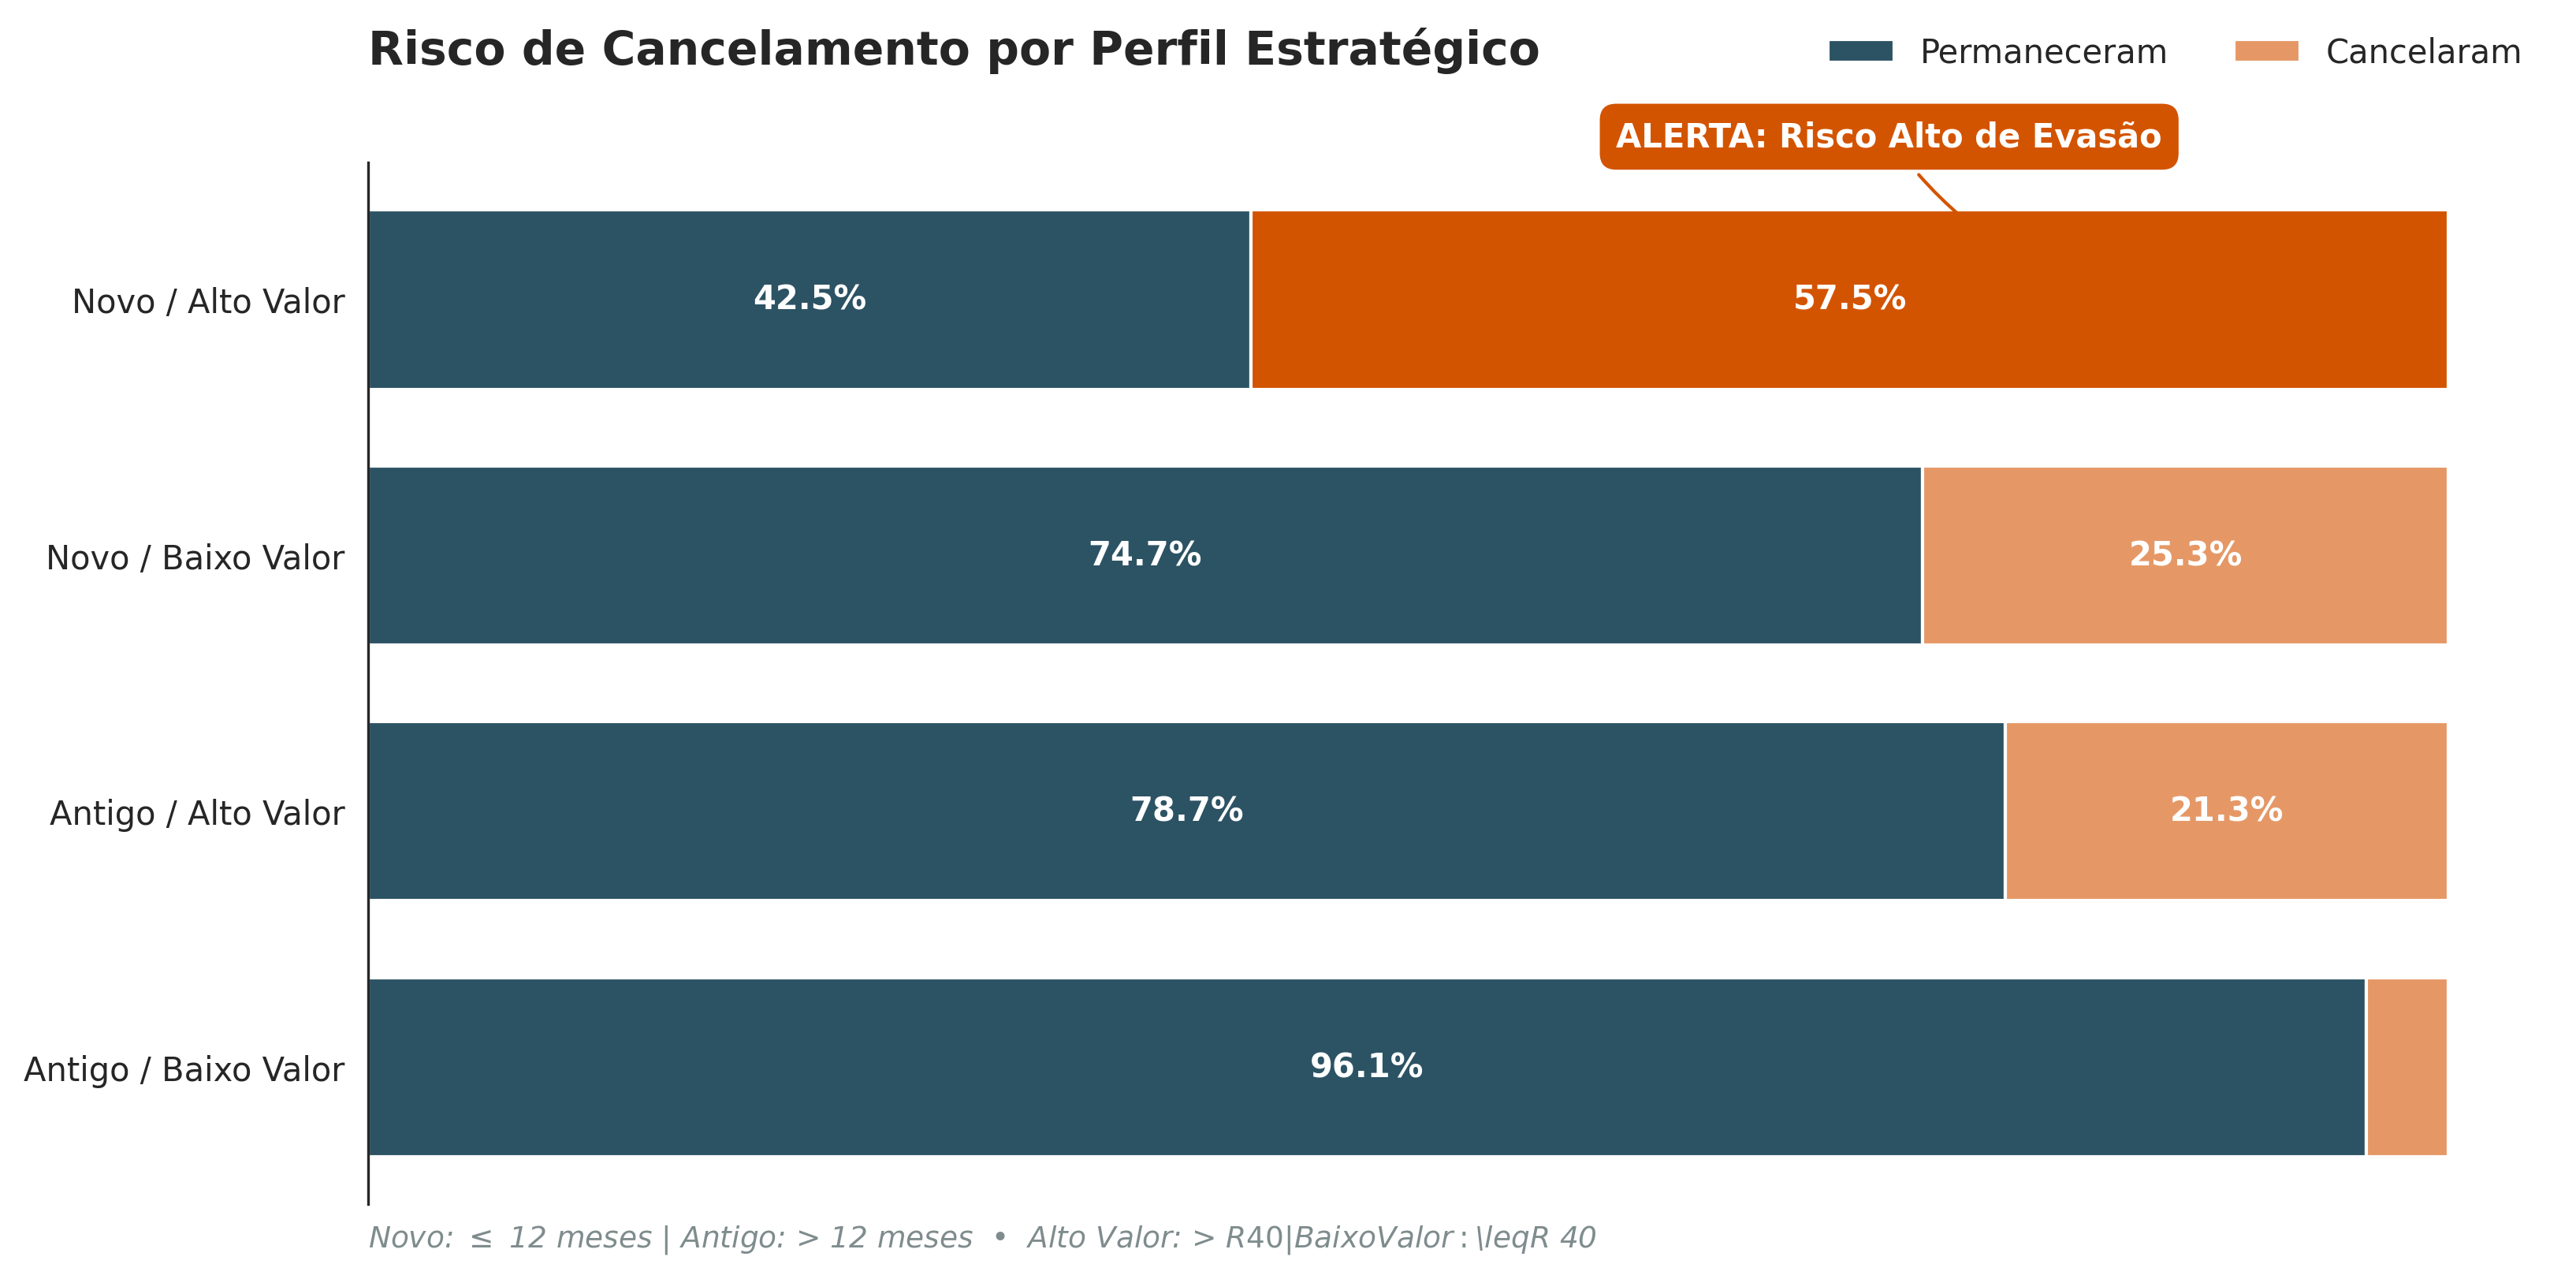

In [108]:
from IPython.display import Image
Image('/content/perfil_risco.png', width=700)

### 4: Conclusões e Insights




Os resultados permitem sintetizar as seguintes conclusões:

* **Gatilho vs. causa raiz:** O preço atua como gatilho imediato de cancelamento, mas a **falta de maturação** é a verdadeira causa raiz.  
* **Barreira de saída psicológica:** Após 18 meses, observa-se efeito de fidelização automática associado ao investimento acumulado e à estabilidade do serviço.  
* **Efeito “combo” e ancoragem:** Serviços complementares, como segurança e pacotes familiares, ampliam a dependência do ecossistema e reduzem o risco de evasão.

### 5: Recomendações Estratégicas



Com base nas evidências, sugerem-se as seguintes ações para redução de churn:

1. **Subsídio de primeiro ano:**  
   Conceder descontos ou benefícios exclusivos durante os primeiros 12 meses, assegurando a transição pela zona de risco inicial e a diluição do CAC.  

2. **Cross-selling de serviços de segurança:**  
   Promover, no momento da venda, a adesão a serviços de segurança, backup e outros complementares que aumentem a dependência da solução.  

3. **Monitoramento ativo de clientes novos com ticket alto:**  
   Implantar alertas no CRM para identificar clientes com pouco tempo de relacionamento e faturas acima da média, oferecendo benefícios extras por tempo limitado como contrapeso ao gatilho de preço.

---

**Analista Responsável:** Tânia Mara F. de Andrade  
**Data:** Dezembro 2025  
**Ferramentas:** Python (Pandas, Seaborn, Matplotlib)

---